# Optimal sensor for IPICS — ice-core R toggle

`R_CORE_MODE` in cell 1 switches the ice-core observation error between the
accumulation model `R = k/A` and a constant `R_CORE_CONST`. Re-run the
`set_ensemble()` cell after changing it; `check_ens()` will refuse to run
any analysis cell against stale arrays.

## Setup


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, xarray as xr, scipy.io as sio
from scipy.spatial import cKDTree
from scipy import ndimage as ndi

%matplotlib inline
import matplotlib.pyplot as plt, matplotlib.path as mpath, matplotlib.patheffects as pe
import cartopy.crs as ccrs
from matplotlib.lines import Line2D
plt.rcParams['figure.dpi'] = 110

DATA = Path('/Users/advik/Library/Mobile Documents/com~apple~CloudDocs/Documents/'
            'Documents - MacBook Air/Python/Ice Cores/data/model/ccsm4_last_millenium')
AWS_MAT      = Path.home()/'Downloads'/'Mathieu'/'Data'/'dataAWS.mat'
ANT11        = Path.home()/'DataFiles'/'ANT11_masks.nc'
GROUNDED_NPY = Path.home()/'DataFiles'/'ANT11_grounded_mask.npy'
CORES_CSV    = Path.home()/'DataFiles'/'WaterCoresCoords.csv'

N_POT_RAW, N_EXIST = 5794, 118
N_SITES_RAW = N_POT_RAW + N_EXIST
EXCLUDE_SITES, EXCLUDE_TOL_KM = [(-66.44, 162.50)], 30.0

# ======================= ENSEMBLE =======================
ENSEMBLE       = 'MRE'      # 'MRE' (160 members) | 'MME' (1001)
VARIABLE       = 'Temp'
ACCUM_ENSEMBLE = 'MRE'      # accumulation source, independent of ENSEMBLE

METRIC_SOURCE        = 'computed'   # 'computed' | 'file'
METRIC_GROUNDED_ONLY = True
METRIC_AREA_WEIGHTED = True

# ================= ICE-CORE OBSERVATION ERROR =================
#   'accumulation' -- R = k/A, k from 42 replicate core pairs. Low-accumulation
#                     sites are penalised, which is physically right but makes
#                     the plateau almost unobservable (R up to ~35 K^2).
#   'constant'     -- R = R_CORE_CONST at every site. Removes the accumulation
#                     penalty entirely; use to isolate the covariance structure
#                     from the noise structure.
R_CORE_MODE  = 'constant'   # 'accumulation' | 'constant'
R_CORE_CONST = 0.0              # K^2, used only when R_CORE_MODE == 'constant'
D18O_TO_T, SIGMA2_D18O, A_CALIB = 2.0, 2.202, 88.2   # k = 2.0^2 * 2.202 * 88.2

# ==================== ICE-SHELF EXCLUSION ====================
EXCLUDE_SHELF    = True
SHELF_SOURCE     = 'imbie'   # 'imbie' | 'moa'  ('moa' is wrong on the Peninsula)
SHELF_ELEV_MAX   = 100.0     # m; kills the shelf-crossing filaments in the mask
MIN_ISLAND       = 10        # cells; kills 2-7 cell specks inside the shelves
SHELF_RADIUS_KM  = 100.0     # a site must be this close to cleaned grounded ice
PROTECT_OBSERVED = True      # never drop a cell hosting an AWS or existing core

# ==================== AWS OBSERVATION ERROR ====================
R_AWS_MODE  = 'constant'  # 'constant' | 'per_station'
R_AWS_CONST = 0.0
R_AWS_NEW   = 0.0            # R for a hypothetical NEW station
R_AWS_VALID = 0.05           # frozen: reproduces the reference table

R_AWS_TC_STATION = {         # triple collocation, station/ERA5 cell/RACMO cell
    'FaradayVernadsky': 0.731, 'Rothera':          0.674, 'Byrd':    0.363,
    'Halley':           0.350, 'ScottBase':        0.301, 'McMurdo': 0.288,
    'AmundsenScott':    0.295, 'Marambio':         0.228, 'Vostok':  0.215,
    'DDU':              0.089, 'Novolazarevskaya': 0.087, 'Neumayer': 0.054,
    'Bellingshausen':   0.038, 'Casey':            0.027, 'Davis':   0.027,
    'Mirny':            0.023, 'Mawson':           0.020,
}
R_AWS_DEFAULT = 0.215
N_BLOCKS, DEBLOCK_MRE = 4, True

def require(*names):
    m = [n for n in names if n not in globals()]
    if m:
        raise RuntimeError(f'run the earlier cells first -- missing {m}')

print('DATA ok:', DATA.exists(), '| AWS ok:', AWS_MAT.exists())
print(f'ENSEMBLE={ENSEMBLE}  ACCUM_ENSEMBLE={ACCUM_ENSEMBLE}')
print(f'R_CORE_MODE={R_CORE_MODE}' +
      (f' (R = {R_CORE_CONST} K^2 everywhere)' if R_CORE_MODE == 'constant' else ' (R = k/A)'))
print(f'R_AWS_MODE={R_AWS_MODE}  EXCLUDE_SHELF={EXCLUDE_SHELF}')


DATA ok: True | AWS ok: True
ENSEMBLE=MRE  ACCUM_ENSEMBLE=MRE
R_CORE_MODE=constant (R = 0.0 K^2 everywhere)
R_AWS_MODE=constant  EXCLUDE_SHELF=True


In [2]:
def read_numbers(p):
    o = []
    for t in Path(p).read_text().split():
        try: o.append(float(t))
        except ValueError: pass
    return np.asarray(o, float)

def haversine_km(a, b, c, d, Rk=6371.0088):
    a, b, c, d = map(np.radians, (a, b, c, d))
    h = np.sin((c-a)/2)**2 + np.cos(a)*np.cos(c)*np.sin((d-b)/2)**2
    return 2*Rk*np.arcsin(np.sqrt(np.clip(h, 0, 1)))

def to_xyz(la, lo):
    la, lo = np.radians(la), np.radians(lo)
    return np.stack([np.cos(la)*np.cos(lo), np.cos(la)*np.sin(lo), np.sin(la)], -1)

def deblock(X, nb=N_BLOCKS):
    """Remove each reanalysis's own mean. The MRE temperature METRIC carries a
    ~40 K ERA5 block offset the ESTIMATES do not. Never applied to MME."""
    X = np.asarray(X, float)
    if X.shape[-1] % nb:
        raise ValueError(X.shape)
    return np.concatenate([b - b.mean(-1, keepdims=True)
                           for b in np.split(X, nb, axis=-1)], axis=-1)

def load_Ye_raw(variable=None, ensemble=None):
    variable = variable or VARIABLE; ensemble = ensemble or ENSEMBLE
    k = f'{variable}{ensemble}Ye'
    Ye = np.asarray(sio.loadmat(DATA / f'{k}.mat')[k], float)
    assert Ye.shape[0] == N_SITES_RAW, Ye.shape
    return deblock(Ye) if (ensemble == 'MRE' and DEBLOCK_MRE) else Ye

def load_file_metric(variable=None, ensemble=None):
    variable = variable or VARIABLE; ensemble = ensemble or ENSEMBLE
    k = f'{ensemble}{variable}'
    Jf = np.asarray(sio.loadmat(DATA / f'{k}.mat')[k], float).ravel()
    return deblock(Jf) if (ensemble == 'MRE' and DEBLOCK_MRE) else Jf

def load_accum_raw(ensemble=None):
    k = f'Accum{ensemble or ACCUM_ENSEMBLE}Ye'
    return np.asarray(sio.loadmat(DATA / f'{k}.mat')[k], float).mean(1)

def build_R_core(accum):
    """Ice-core observation error, per the R_CORE_MODE toggle."""
    if R_CORE_MODE == 'accumulation':
        return D18O_TO_T**2 * SIGMA2_D18O * A_CALIB / accum
    if R_CORE_MODE == 'constant':
        return np.full(accum.shape, float(R_CORE_CONST))
    raise ValueError(R_CORE_MODE)

print('helpers defined (nothing loaded yet)')


helpers defined (nothing loaded yet)


In [3]:
require('DATA', 'haversine_km')
ccsm_lat = np.linspace(-90, 90, 192)
ccsm_lon = np.arange(288) * 1.25

def build_site_coords():
    era = xr.open_dataset(DATA / 'data.nc')
    t2m = era[list(era.data_vars)[0]].values
    tm = np.roll(t2m, 1800, axis=2)
    li = pd.read_csv(DATA / 'latInd.csv').values.ravel().astype(int)
    tr = np.zeros((32, 3600))
    for i, it in enumerate(li):
        tr[i, :] = tm[0, it]
    sec = np.zeros((32, 7200))
    for i in range(32):
        sec[i, :7198] = np.dstack((tr[i, :-1],
                                   tr[i, :-1] + np.diff(tr[i])/2.0)).ravel()
    rg = sec[:, ::25]
    la, lo = [], []
    for i in range(32):
        for j in range(288):
            if rg[i, j] > 0:
                la.append(ccsm_lat[i]); lo.append(ccsm_lon[j])
    return np.array(la), np.array(lo)

site_lat_raw, site_lon_raw = build_site_coords()
assert site_lat_raw.size == N_POT_RAW

drop = np.zeros(N_POT_RAW, bool)
for la, lo in EXCLUDE_SITES:
    drop |= haversine_km(la, np.mod(lo, 360.), site_lat_raw, site_lon_raw) < EXCLUDE_TOL_KM

# ANT11 lookup on the RAW coordinates, before anything is sliced
_a11 = xr.open_dataset(ANT11)
_ice = _a11['Icesheet_Only'].values > 0.5
_aB, _aT = _a11['Basins'].values[_ice], _a11['Topography'].values[_ice]
_aLA = _a11['lat'].values[_ice]
_aLO = np.mod(_a11['lon'].values, 360.)[_ice]
_aG  = np.load(GROUNDED_NPY)[_ice]
_dist, _idx = cKDTree(to_xyz(_aLA, _aLO)).query(to_xyz(site_lat_raw, site_lon_raw))
_km = 2*6371.0088*np.arcsin(np.clip(_dist/2, 0, 1))
gr_imbie_raw, too_far_raw = _aG[_idx], _km > 150
basin_raw, elev_raw = _aB[_idx], _aT[_idx]

_gl = pd.read_csv(DATA / 'IceShelfMask.csv')['Mask'].values.astype(float)
shelf_moa_raw = site_lat_raw > _gl[(np.round(site_lon_raw/1.25).astype(int)) % 288]

# clean the grounded mask: drop shelf-elevation filaments and tiny specks
_gr_full   = np.load(GROUNDED_NPY)
_ice_full  = _a11['Icesheet_Only'].values > 0.5
_topo_full = _a11['Topography'].values
_Vf = _ice_full & (_gr_full > 0.5 if _gr_full.dtype != bool else _gr_full)
if SHELF_ELEV_MAX > 0:
    _Vf &= _topo_full > SHELF_ELEV_MAX
if MIN_ISLAND > 1:
    _lb, _nn = ndi.label(_Vf, structure=np.ones((3, 3), bool))
    _szz = ndi.sum(_Vf, _lb, range(1, _nn + 1))
    _Vf &= ~np.isin(_lb, np.flatnonzero(_szz < MIN_ISLAND) + 1)
_clat = _a11['lat'].values[_Vf]
_clon = np.mod(_a11['lon'].values, 360.)[_Vf]
_dc, _ = cKDTree(to_xyz(_clat, _clon)).query(to_xyz(site_lat_raw, site_lon_raw))
clean_km = 2*6371.0088*np.arcsin(np.clip(_dc/2, 0, 1))

if not EXCLUDE_SHELF:
    shelf_drop = np.zeros(N_POT_RAW, bool)
elif SHELF_SOURCE == 'imbie':
    shelf_drop = (~gr_imbie_raw) | too_far_raw | (clean_km > SHELF_RADIUS_KM)
elif SHELF_SOURCE == 'moa':
    shelf_drop = shelf_moa_raw
else:
    raise ValueError(SHELF_SOURCE)

if EXCLUDE_SHELF and SHELF_SOURCE == 'imbie' and PROTECT_OBSERVED:
    _ob  = pd.read_csv(CORES_CSV, header=None, names=['name', 'alt', 'lat', 'lon'])
    _ola = _ob.lat.astype(float).values
    _olo = np.mod(_ob.lon.astype(float).values, 360.)
    _aw  = sio.loadmat(AWS_MAT, squeeze_me=True, struct_as_record=False)['dataAWS']
    for _n in _aw._fieldnames:
        _r = getattr(_aw, _n)
        _ola = np.append(_ola, float(_r.lat))
        _olo = np.append(_olo, np.mod(float(_r.lon), 360.))
    _pi = np.unique([int(np.argmin(haversine_km(a, b, site_lat_raw, site_lon_raw)))
                     for a, b in zip(_ola, _olo)])
    _resc = int(shelf_drop[_pi].sum()); shelf_drop[_pi] = False
    print(f'  protected {len(_pi)} observed cells, rescued {_resc}')

keep_pot = ~drop & ~shelf_drop
site_lat, site_lon = site_lat_raw[keep_pot], site_lon_raw[keep_pot]
N_POTENTIAL = int(keep_pot.sum())
is_shelf            = shelf_moa_raw[keep_pot]
site_grounded_imbie = gr_imbie_raw[keep_pot]
too_far             = too_far_raw[keep_pot]
site_basin, site_elev = basin_raw[keep_pot], elev_raw[keep_pot]
grounded = np.ones(N_POTENTIAL, bool) if EXCLUDE_SHELF else ~is_shelf
wts = np.cos(np.deg2rad(site_lat))
print(f'EXCLUDE_SHELF={EXCLUDE_SHELF} ({SHELF_SOURCE}): dropped '
      f'{int(shelf_drop.sum())} floating + {int(drop.sum())} named '
      f'-> N_POTENTIAL {N_POT_RAW} -> {N_POTENTIAL}')


  protected 77 observed cells, rescued 9
EXCLUDE_SHELF=True (imbie): dropped 499 floating + 1 named -> N_POTENTIAL 5794 -> 5295


In [4]:
require('site_lat', 'site_basin', 'site_elev')

REGIONS = {'EAIS': [2, 4, 5, 7, 9, 12, 13, 14, 15, 17],
           'WAIS': [1, 18, 20, 21, 23],
           'AP':   [24, 25, 27]}
region_mask = {rn: (np.isin(site_basin, ids) & site_grounded_imbie & ~too_far)
               for rn, ids in REGIONS.items()}

# --- PAGES Ant-2K regions (Stenni et al. 2017), port of regions_Ant2K.m ---
PLATEAU_ALTI, PENI, WED, B_AI = 2000.0, -74.0, 330.0, 67.0
_VIC = """-85 150
-84 150
-83 149
-82 148
-81 147
-80 149
-79 150
-78 150
-77 150
-76 155
-75 160
-74 160
-73 160
-72 160
-71 160
-70 160
-69 160
-68 160
-67 160
-66 160
-65 160
-64 160
-63 160"""
vic_tab = np.array([[float(x) for x in l.split()] for l in _VIC.strip().splitlines()])
vic_ord = np.argsort(vic_tab[:, 0])
lats_v, vlim = vic_tab[vic_ord, 0], vic_tab[vic_ord, 1]

def regions_ant2k(lat, lon, elevi, edml_zero=False):
    """Rules applied in order, later ones overwriting -- as in the MATLAB.
    edml_zero=True reproduces the original's region-0 bug; False is the fix."""
    lat = np.asarray(lat, float); lon = np.asarray(lon, float)
    elevi = np.asarray(elevi, float); sh = lat.shape
    vlat = lat.ravel(); vlon = np.mod(lon.ravel(), 360.); ve = elevi.ravel()
    reg = np.full(vlat.shape, np.nan)
    vll = np.interp(vlat, lats_v, vlim, left=np.nan, right=np.nan)
    with np.errstate(invalid='ignore'):
        reg[(vlon < 145) & (ve > PLATEAU_ALTI)] = 1
        reg[(vlon >= 145) & (vlon < 190) & (ve >= 0) & (vlon < vll)] = 1
        reg[(vlon >= 145) & (vlon < 350) & (vlat < -84) & (ve >= 0)] = 1
        f = 0. if edml_zero else 1.
        reg[(vlon < 30) & (ve > PLATEAU_ALTI)] = f
        reg[(vlon >= 300) & (ve > PLATEAU_ALTI)] = f
        reg[(vlon > WED) & (ve < PLATEAU_ALTI) & (vlat > -76) & (ve >= 0)] = 7
        reg[(vlon > 0) & (vlon < B_AI) & (ve < PLATEAU_ALTI)] = 7
        reg[(vlon > WED) & (ve < PLATEAU_ALTI) & (vlat < -75) & (ve >= 0)] = 3
        reg[(vlon >= 300) & (vlon < WED) & (ve < PLATEAU_ALTI)] = 3
        reg[(vlon >= B_AI) & (vlon < 145) & (ve < PLATEAU_ALTI)] = 2
        reg[(vlon >= 145) & (vlon < 160) & (ve >= 0) & (vlon < vll)
            & (ve < PLATEAU_ALTI) & (vlat > -72)] = 2
        reg[(vlon >= 145) & (vlon < 190) & (ve >= 0) & (vlat < -74) & (vlon > vll)] = 6
        reg[(vlon >= 160) & (vlon < 190) & (ve >= 0) & (vlon > vll)] = 6
        reg[(vlon >= 190) & (vlon < 280) & (vlat > -85) & (ve >= 0)] = 5
        reg[(vlon >= 280) & (vlon < 300) & (vlat > -85) & (vlat < PENI+.5) & (ve >= 0)] = 5
        reg[(vlon >= 280) & (vlon < 305) & (vlat > PENI) & (ve >= 0)] = 4
    return reg.reshape(sh)

P2K_NAMES = {1: 'East Antarctic Plateau', 2: 'Wilkes Land Coast',
             3: 'Weddell Sea Coast', 4: 'Antarctic Peninsula', 5: 'WAIS',
             6: 'Victoria Land / Ross Sea', 7: 'Dronning Maud Land Coast'}
SHORT = ['Plateau', 'Wilkes', 'Weddell', 'Peninsula', 'WAIS', 'Vic.Land/Ross', 'DML']
site_region = regions_ant2k(site_lat, site_lon, site_elev, edml_zero=False)
p2k_mask = {v: ((site_region == v) & site_grounded_imbie & ~too_far)
            for v in range(1, 8)}
print(f'{"region":32s} {"sites":>6s} {"weight":>8s}')
for v, nm in P2K_NAMES.items():
    print(f'{v} {nm:30s} {p2k_mask[v].sum():6d} '
          f'{100*wts[p2k_mask[v]].sum()/wts.sum():7.1f}%')


region                            sites   weight
1 East Antarctic Plateau           3677    58.7%
2 Wilkes Land Coast                 183     7.8%
3 Weddell Sea Coast                 272     4.8%
4 Antarctic Peninsula                70     2.7%
5 WAIS                              767    16.1%
6 Victoria Land / Ross Sea          145     3.2%
7 Dronning Maud Land Coast          157     6.0%


In [5]:
require('site_lat')
_aws = sio.loadmat(AWS_MAT, squeeze_me=True, struct_as_record=False)['dataAWS']
rows = []
for n_ in _aws._fieldnames:
    r = getattr(_aws, n_)
    la, lo = float(r.lat), np.mod(float(r.lon), 360.0)
    d = haversine_km(la, lo, site_lat, site_lon); k = int(np.argmin(d))
    rows.append(dict(station=n_, lat=la, lon=lo, site=k, km=d[k]))
aws_map = pd.DataFrame(rows)
AWS_SITES = sorted(set(aws_map.site))
print(f'{len(aws_map)} stations -> {len(AWS_SITES)} cells, '
      f'max offset {aws_map.km.max():.0f} km')
aws_map.round(1)


17 stations -> 16 cells, max offset 125 km


,station,lat,lon,site,km
0,FaradayVernadsky,-65.1,295.8,5286,43.9
1,Rothera,-67.3,291.9,5258,25.3
2,Byrd,-80.0,240.7,3128,43.3
3,Marambio,-64.2,303.4,5293,124.9
4,Mawson,-67.6,62.9,5137,82.3
5,Davis,-68.6,78.0,5144,43.3
6,McMurdo,-77.9,166.7,3554,25.2
7,DDU,-66.7,140.0,5253,75.9
8,Bellingshausen,-62.1,301.4,5294,95.4
9,Neumayer,-70.4,351.8,4910,86.3


In [6]:
require('site_lat', 'grounded', 'keep_pot')

def build_metric(Ye, mask=None, weights=None):
    """cos(lat)-weighted spatial mean of the estimates over `mask`."""
    Y = Ye[:N_POTENTIAL]
    m = np.ones(N_POTENTIAL, bool) if mask is None else np.asarray(mask, bool)
    if weights is None:
        w = np.cos(np.deg2rad(site_lat)) if METRIC_AREA_WEIGHTED \
            else np.ones(N_POTENTIAL)
    else:
        w = np.asarray(weights, float)
    w = w[m]
    return (Y[m] * w[:, None]).sum(0) / w.sum()

def set_ensemble(ens=None):
    """Rebuild every ensemble- and R-dependent array FROM DISK. Idempotent, so
    re-run it after changing ENSEMBLE, ACCUM_ENSEMBLE or R_CORE_MODE."""
    global ENSEMBLE, Ye, nM, unbias, J, J_computed, J_file, J0var
    global accum_rate, R_ICE_CORE, metric_mask, ENS_STAMP
    if ens is not None:
        ENSEMBLE = ens
    raw = load_Ye_raw()
    Ye  = np.concatenate([raw[:N_POT_RAW][keep_pot], raw[N_POT_RAW:]])
    nM, unbias = Ye.shape[1], 1/(Ye.shape[1] - 1)
    metric_mask = grounded if METRIC_GROUNDED_ONLY else np.ones(N_POTENTIAL, bool)
    J_computed  = build_metric(Ye, mask=metric_mask)
    J_file      = load_file_metric()
    J = J_computed if METRIC_SOURCE == 'computed' else J_file
    J0var = unbias * ((J - J.mean())**2).sum()
    accum_rate = load_accum_raw()[:N_POT_RAW][keep_pot]
    R_ICE_CORE = build_R_core(accum_rate)
    ENS_STAMP = (ENSEMBLE, VARIABLE, METRIC_SOURCE, ACCUM_ENSEMBLE,
                 R_CORE_MODE, R_CORE_CONST, nM, Ye.shape)
    print(f'ENSEMBLE={ENSEMBLE}  METRIC_SOURCE={METRIC_SOURCE}')
    print(f'  Ye {Ye.shape}   nM {nM}   DOF {nM-1}')
    print(f'  J: mean {J.mean():.3f} K   sd {J.std(ddof=1):.4f} K   var {J0var:.5f}')
    print(f'  R_CORE_MODE={R_CORE_MODE} -> R_ICE_CORE median '
          f'{np.median(R_ICE_CORE):.2f} K^2, range {R_ICE_CORE.min():.2f}'
          f' .. {R_ICE_CORE.max():.2f}')
    return ENS_STAMP

def check_ens():
    """First line of every analysis cell. Turns silent drift into an error."""
    want = (ENSEMBLE, VARIABLE, METRIC_SOURCE, ACCUM_ENSEMBLE,
            R_CORE_MODE, R_CORE_CONST, nM, Ye.shape)
    if ENS_STAMP != want:
        raise RuntimeError(f'stale state: arrays built as {ENS_STAMP}, config '
                           f'now says {want}. Re-run set_ensemble().')

set_ensemble()


ENSEMBLE=MRE  METRIC_SOURCE=computed
  Ye (5413, 160)   nM 160   DOF 159
  J: mean 0.000 K   sd 0.5529 K   var 0.30568
  R_CORE_MODE=constant -> R_ICE_CORE median 0.00 K^2, range 0.00 .. 0.00


('MRE', 'Temp', 'computed', 'MRE', 'constant', 0.0, 160, (5413, 160))

In [7]:
TINY = 1e-12

def variance_reduction(Jdev, Ydev, Rvar, unb):
    den = unb * (Ydev**2).sum(1) + Rvar
    num = (unb * (Ydev @ Jdev))**2
    return np.where(den > TINY, num / np.where(den > TINY, den, 1.0), 0.0)

def adjusted_gain(Kn, Kd, Rb):
    ks = np.sqrt(Kd); return Kn / ks / (ks + np.sqrt(Rb))

class OptimalSensor:
    """DASH @optimalSensor (Comboul et al. 2015)."""
    def __init__(self, J, Ye, R):
        J = np.asarray(J, float).ravel()
        self.nM = J.size; self.unbias = 1/(self.nM - 1)
        self.Jdev = J - J.mean()
        Ye = np.asarray(Ye, float)
        self.Ydev = Ye - Ye.mean(1, keepdims=True)
        self.R = (np.full(Ye.shape[0], float(R)) if np.isscalar(R)
                  else np.asarray(R, float).ravel().copy())
        self.J0var = self.metric_variance()

    def metric_variance(self):
        return self.unbias * (self.Jdev**2).sum()

    def evaluate(self):
        return variance_reduction(self.Jdev, self.Ydev, self.R, self.unbias)

    def assimilate(self, i, Rval=None):
        Yb = self.Ydev[i].copy()
        Rb = self.R[i] if Rval is None else Rval
        Yv = self.unbias * (Yb**2).sum()
        if Yv + Rb <= TINY:
            self.Ydev[i] = np.nan
            return self.metric_variance()
        Ka = adjusted_gain(self.unbias * (self.Jdev @ Yb), Yv + Rb, Rb)
        self.Jdev = self.Jdev - Ka*Yb
        self.Ydev = self.Ydev - Ka*Yb
        self.Ydev[i] = np.nan
        return self.metric_variance()

print('OptimalSensor defined')


OptimalSensor defined


In [8]:
require('aws_map', 'AWS_SITES')

def build_R_aws():
    """R_aws(site). Two stations sharing a cell (McMurdo/Scott Base) average."""
    t = aws_map.assign(R=aws_map.station.map(R_AWS_TC_STATION))
    site_R = {int(k): float(v) for k, v in
              t.dropna(subset=['R']).groupby('site').R.mean().items()}
    if R_AWS_MODE == 'per_station':
        f = lambda i: site_R.get(int(i), R_AWS_DEFAULT)
    elif R_AWS_MODE == 'constant':
        f = lambda i: R_AWS_CONST
    else:
        raise ValueError(R_AWS_MODE)
    return f, site_R

R_aws, R_AWS_SITE = build_R_aws()
print(f'R_AWS_MODE = {R_AWS_MODE}' +
      (f'   R = {R_AWS_CONST} for all {len(AWS_SITES)} cells'
       if R_AWS_MODE == 'constant' else
       f'   {len(R_AWS_SITE)}/{len(AWS_SITES)} cells from the TC table'))


R_AWS_MODE = constant   R = 0.0 for all 16 cells


In [9]:
require('site_lat')
cc = pd.read_csv(CORES_CSV, header=None, names=['name', 'alt', 'lat', 'lon'])
cc['lat'] = cc.lat.astype(float)
cc['lon'] = np.mod(cc.lon.astype(float), 360.)
_d = np.array([haversine_km(a, b, site_lat, site_lon) for a, b in zip(cc.lat, cc.lon)])
cc['site'] = _d.argmin(1); cc['km'] = _d.min(1)
CORE_SITES = sorted(set(cc.site))
core_mask = np.zeros(N_POTENTIAL, bool); core_mask[CORE_SITES] = True
name_of = {}
for s_, n_ in zip(cc.site, cc.name):
    name_of.setdefault(int(s_), n_)
print(f'{len(cc)} existing cores -> {len(CORE_SITES)} unique cells '
      f'(median offset {cc.km.median():.0f} km)')


80 existing cores -> 63 unique cells (median offset 27 km)


In [10]:
check_ens()
_ky, _kj = f'{VARIABLE}{ENSEMBLE}Ye', f'{ENSEMBLE}{VARIABLE}'
Ye_raw = np.asarray(sio.loadmat(DATA / f'{_ky}.mat')[_ky], float)
J_raw  = np.asarray(sio.loadmat(DATA / f'{_kj}.mat')[_kj], float).ravel()
tgt    = read_numbers(DATA / f'BS_{ENSEMBLE}_{VARIABLE.lower()}_accumR.csv')
dv_chk = OptimalSensor(J_raw, Ye_raw[:N_POT_RAW],
                       read_numbers(DATA / 'RSheet.csv')[:N_POT_RAW]).evaluate()
corr = np.corrcoef(dv_chk, tgt)[0, 1]
rel  = np.max(np.abs(dv_chk - tgt) / np.maximum(np.abs(tgt), 1e-30))
print(f'algorithm check: 1 - corr {1-corr:.3e}   max rel err {rel:.3e}')
assert corr > 1 - 1e-8 and rel < 1e-3, 'does not match MATLAB'
print('matches the MATLAB output to the precision of the reference file')


algorithm check: 1 - corr 1.289e-10   max rel err 4.894e-05
matches the MATLAB output to the precision of the reference file


In [11]:
check_ens(); require('p2k_mask', 'AWS_SITES')
# NOTE: this table assimilates the AWS network at the frozen R_AWS_VALID and
# never uses R_ICE_CORE, so it is INDEPENDENT of R_CORE_MODE by construction.
rows = []
for lbl, Jm in ([('AIS-wide', J)] +
                [(f'{v}. {P2K_NAMES[v]}', build_metric(Ye, mask=p2k_mask[v]))
                 for v in range(1, 8)]):
    ob = OptimalSensor(Jm, Ye[:N_POTENTIAL], R_ICE_CORE)
    J0m = ob.J0var
    for i in AWS_SITES:
        ob.assimilate(int(i), Rval=R_AWS_VALID)
    v0m = ob.metric_variance()
    rows.append(dict(metric=lbl, var=J0m, remaining=v0m,
                     constrained_pct=100*(1 - v0m/J0m)))
REG = pd.DataFrame(rows)
print(f'FROZEN VALIDATION at R = {R_AWS_VALID}, {nM} members, '
      f'EXCLUDE_SHELF={EXCLUDE_SHELF}\n')
print(REG.round(4).to_string(index=False))
REF = [92.4946, 92.0159, 92.8527, 58.1998, 80.6740, 85.8563, 78.8332, 89.0512]
ok = (EXCLUDE_SHELF and SHELF_SOURCE == 'imbie' and ENSEMBLE == 'MRE'
      and np.allclose(REG.constrained_pct.values, REF, atol=1e-3))
print(f'\nregression vs reference: '
      f'{"PASS" if ok else "not applicable / FAIL for this configuration"}')


FROZEN VALIDATION at R = 0.05, 160 members, EXCLUDE_SHELF=True

                     metric    var  remaining  constrained_pct
                   AIS-wide 0.3057     0.0229          92.4946
  1. East Antarctic Plateau 0.4244     0.0339          92.0159
       2. Wilkes Land Coast 0.4651     0.0332          92.8527
       3. Weddell Sea Coast 0.6074     0.2539          58.1998
     4. Antarctic Peninsula 0.7379     0.1426          80.6740
                    5. WAIS 0.5487     0.0776          85.8563
6. Victoria Land / Ross Sea 0.4913     0.1040          78.8332
7. Dronning Maud Land Coast 0.3197     0.0350          89.0512

regression vs reference: PASS


In [12]:
check_ens(); require('site_lat', 'aws_map')
SP, PL = ccrs.SouthPolarStereo(), ccrs.PlateCarree()
CMAP = plt.cm.Greens

LAT32 = ccsm_lat[:32]
_gi = np.searchsorted(LAT32, site_lat)
_gj = (np.round(site_lon/1.25).astype(int)) % 288
assert np.allclose(LAT32[_gi], site_lat) and np.allclose(ccsm_lon[_gj], site_lon)
_dlat = np.diff(LAT32).mean()
LAT_E = np.concatenate([LAT32 - _dlat/2, [LAT32[-1] + _dlat/2]])
LON_E = np.concatenate([ccsm_lon - 0.625, [ccsm_lon[-1] + 0.625]])

def to_grid(v):
    v = np.asarray(v, float)
    if v.size != N_POTENTIAL:
        raise ValueError(f'expected {N_POTENTIAL} values, got {v.size}')
    g = np.full((32, 288), np.nan); g[_gi, _gj] = v
    return g

def polar_ax(ax):
    ax.set_extent([-180, 180, -90, -60], PL)
    th = np.linspace(0, 2*np.pi, 200)
    ax.set_boundary(mpath.Path(np.stack([np.cos(th), np.sin(th)], 1)*.5+.5),
                    transform=ax.transAxes)
    ax.gridlines(linewidth=.3, color='0.7'); ax.coastlines(linewidth=.7)

def field_map(pct, title, ax=None, fig=None, vmax=None, show_aws=False,
              cb=True, fs=12, cmap=None):
    if ax is None:
        fig = plt.figure(figsize=(11, 10)); ax = plt.axes(projection=SP)
    polar_ax(ax)
    vmax = float(np.nanmax(pct)) if vmax is None else vmax
    sc = ax.pcolormesh(LON_E, LAT_E, np.ma.masked_invalid(to_grid(pct)),
                       cmap=cmap or CMAP, vmin=0, vmax=vmax, transform=PL,
                       zorder=1, shading='flat')
    if show_aws:
        ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=55, c='red',
                   edgecolors='k', lw=.5, transform=PL, zorder=3)
    if cb:
        c = fig.colorbar(sc, ax=ax, shrink=.62, pad=.04)
        c.set_label('% of total variance constrained')
    ax.set_title(title, fontsize=fs)
    return sc

print('plot helpers ready')


plot helpers ready


In [13]:
check_ens(); require('regions_ant2k', 'SP')
# Boundaries on the native ANT11 grid, with the same mask cleaning as cell 3.
_d2    = xr.open_dataset(ANT11)
_lat2  = _d2['lat'].values
_lon2  = np.mod(_d2['lon'].values, 360.)
_topo2 = _d2['Topography'].values
_ice2  = _d2['Icesheet_Only'].values > 0.5
_gr2   = np.load(GROUNDED_NPY)
BND_VALID = _ice2 & (_gr2 > 0.5 if _gr2.dtype != bool else _gr2)
if SHELF_ELEV_MAX > 0:
    BND_VALID &= _topo2 > SHELF_ELEV_MAX
if MIN_ISLAND > 1:
    _lb2, _n2 = ndi.label(BND_VALID, structure=np.ones((3, 3), bool))
    _sz2 = ndi.sum(BND_VALID, _lb2, range(1, _n2 + 1))
    BND_VALID &= ~np.isin(_lb2, np.flatnonzero(_sz2 < MIN_ISLAND) + 1)
BND_REG = regions_ant2k(_lat2, _lon2, _topo2, edml_zero=False)
BND_REG = np.where(BND_VALID, BND_REG, np.nan)
_XY = SP.transform_points(PL, _lon2, _lat2)
BND_X, BND_Y = _XY[:, :, 0], _XY[:, :, 1]
REG_FILL, REG_EDGE = '#ffcc80', '#e08214'

def outline_region(ax, v, lw=1.3):
    Z = np.nan_to_num(np.where(BND_VALID,
                               ((BND_REG == v) if v else BND_VALID).astype(float), 0.0))
    ax.contour(BND_X, BND_Y, Z, levels=[0.5], colors=[REG_EDGE], linewidths=lw,
               transform=SP, zorder=5)

def fill_region(ax, v):
    Z = np.nan_to_num(np.where(BND_VALID,
                               ((BND_REG == v) if v else BND_VALID).astype(float), 0.0))
    ax.contourf(BND_X, BND_Y, Z, levels=[0.5, 1.5], colors=[REG_FILL],
                alpha=.9, transform=SP, zorder=1)
    ax.contour(BND_X, BND_Y, Z, levels=[0.5], colors=[REG_EDGE], linewidths=1.1,
               transform=SP, zorder=1.5)

METS = ([('AIS-wide', J, 0)] +
        [(f'{v}. {P2K_NAMES[v]}', build_metric(Ye, mask=p2k_mask[v]), v)
         for v in range(1, 8)])
print(f'{int(BND_VALID.sum())} grounded ANT11 cells; unassigned '
      f'{int((BND_VALID & ~np.isin(np.nan_to_num(BND_REG, nan=-1), list(range(1,8)))).sum())}')


99543 grounded ANT11 cells; unassigned 0


## The R toggle


              mode  R_min  R_med  R_max  snr_med  in_use
accumulation (k/A)  0.318 10.813 47.864     0.05   False
    constant (0.0)  0.000  0.000  0.000     1.00    True

R_CORE_CONST = 0.0 sits at the 0th percentile of the k/A field


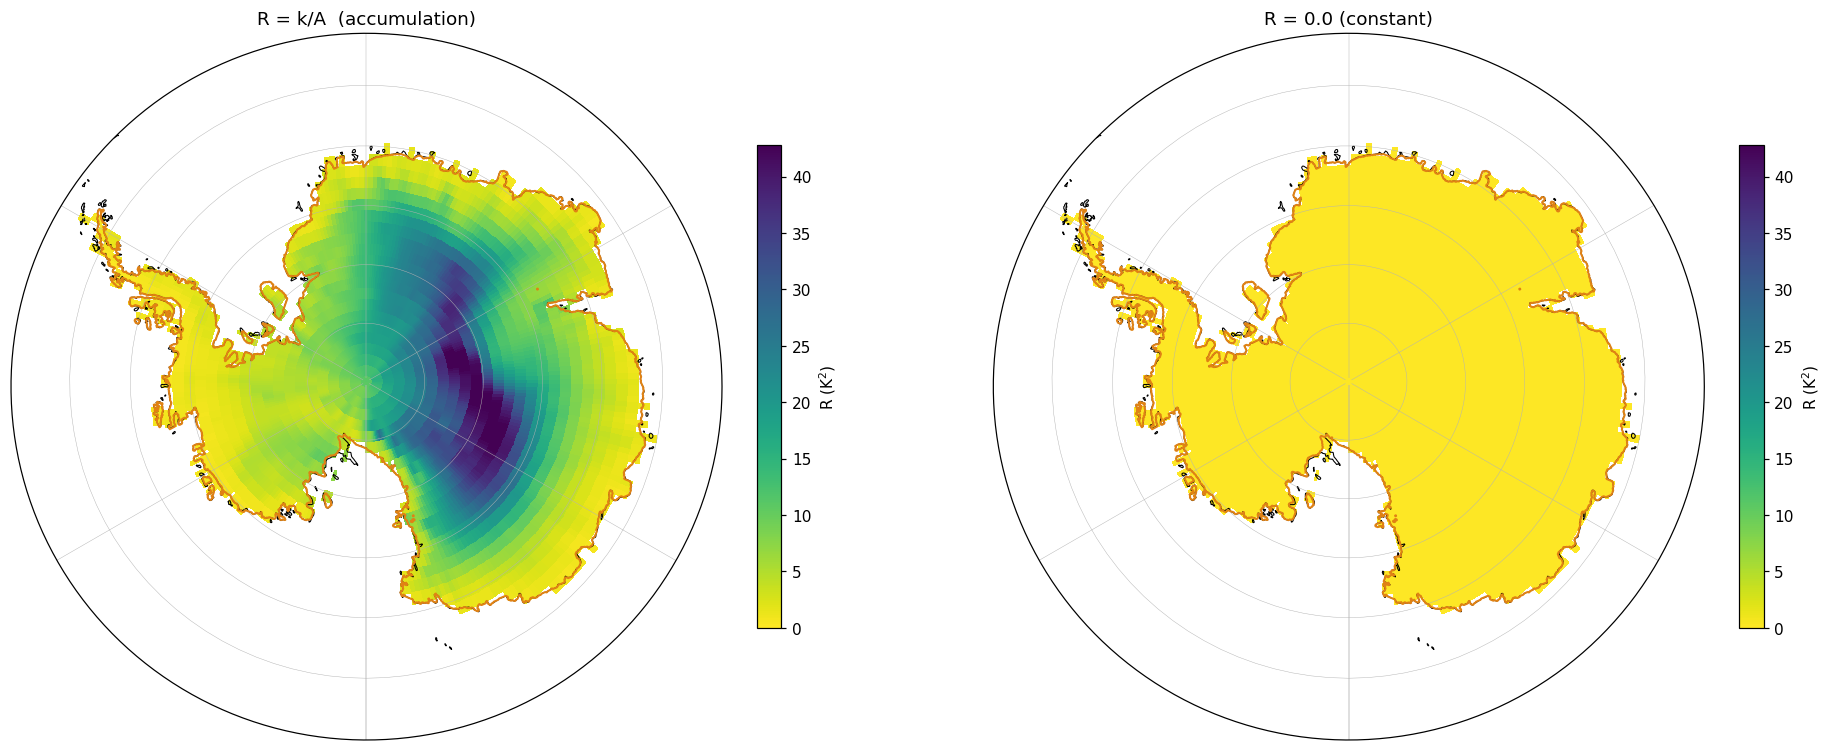

In [14]:
check_ens(); require('to_grid', 'outline_region')
# What the R toggle actually does, side by side.
R_acc = D18O_TO_T**2 * SIGMA2_D18O * A_CALIB / accum_rate
R_con = np.full(N_POTENTIAL, float(R_CORE_CONST))
snr = lambda R: (unbias*((Ye[:N_POTENTIAL]-Ye[:N_POTENTIAL].mean(1,keepdims=True))**2).sum(1)) / \
                (unbias*((Ye[:N_POTENTIAL]-Ye[:N_POTENTIAL].mean(1,keepdims=True))**2).sum(1) + R)
print(pd.DataFrame({
    'mode': ['accumulation (k/A)', f'constant ({R_CORE_CONST})'],
    'R_min':  [R_acc.min(),  R_con.min()],
    'R_med':  [np.median(R_acc), np.median(R_con)],
    'R_max':  [R_acc.max(),  R_con.max()],
    'snr_med':[np.median(snr(R_acc)), np.median(snr(R_con))],
    'in_use': [R_CORE_MODE == 'accumulation', R_CORE_MODE == 'constant'],
}).round(3).to_string(index=False))
print(f'\nR_CORE_CONST = {R_CORE_CONST} sits at the '
      f'{100*(R_acc < R_CORE_CONST).mean():.0f}th percentile of the k/A field')

fig = plt.figure(figsize=(19, 8.5))
for i, (Rf, ttl) in enumerate([(R_acc, 'R = k/A  (accumulation)'),
                               (R_con, f'R = {R_CORE_CONST} (constant)')]):
    ax = fig.add_axes([0.03 + i*0.47, 0.05, 0.42, 0.86], projection=SP)
    sc = field_map(np.clip(Rf, 0, np.percentile(R_acc, 99)), ttl, ax=ax, fig=fig,
                   cb=False, cmap=plt.cm.viridis_r,
                   vmax=float(np.percentile(R_acc, 99)))
    outline_region(ax, 0)
    cb = fig.colorbar(sc, ax=ax, shrink=.6, pad=.04); cb.set_label('R (K$^2$)')
plt.show()


## Blank slate


--- blank slate: one new ICE CORE (R_CORE_MODE=constant) ---
                     metric  max_pct    lat    lon  accum   R  in_region  mean_pct
                   AIS-wide    72.09 -75.86  55.00  52.08 0.0       True     43.75
  1. East Antarctic Plateau    82.67 -75.86  53.75  48.31 0.0       True     43.74
       2. Wilkes Land Coast    79.54 -67.38 122.50 644.84 0.0       True     34.01
       3. Weddell Sea Coast    96.04 -81.52 331.25 114.18 0.0       True     17.74
     4. Antarctic Peninsula    91.07 -71.15 288.75 945.08 0.0       True      5.51
                    5. WAIS    89.29 -81.52 241.25 135.92 0.0       True     18.20
6. Victoria Land / Ross Sea    89.51 -76.81 157.50  54.56 0.0       True     22.91
7. Dronning Maud Land Coast    86.86 -71.15  32.50 243.95 0.0       True     35.12


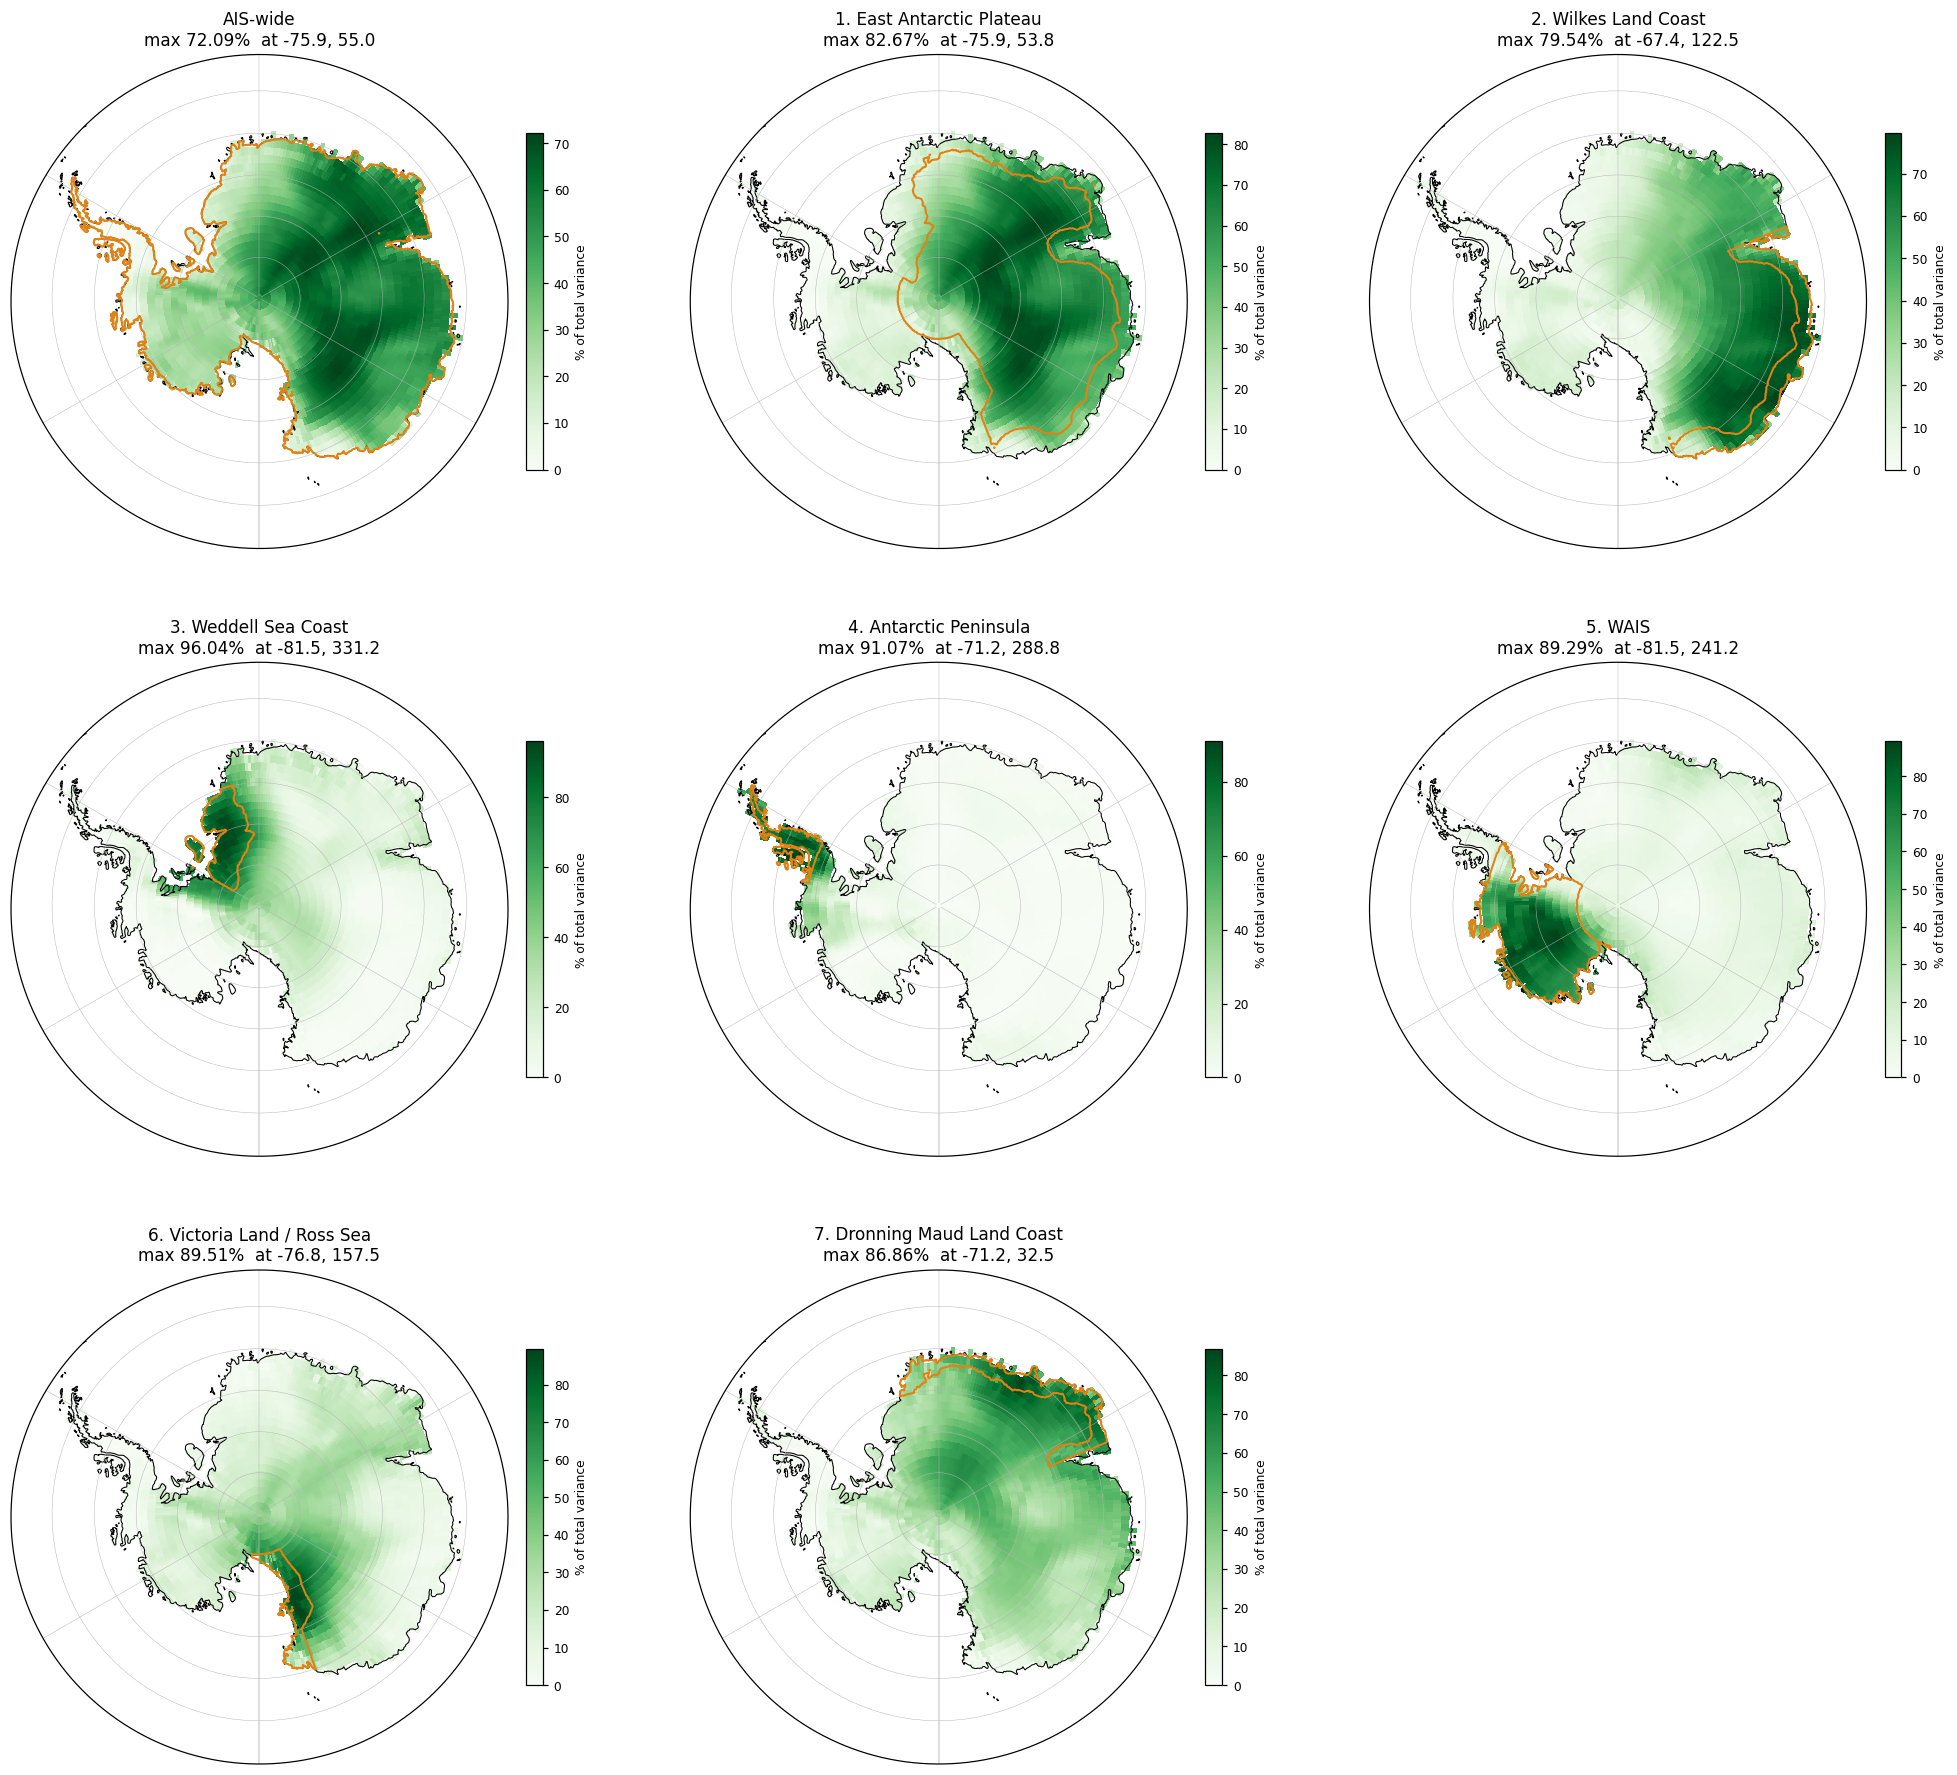

In [15]:
check_ens(); require('METS', 'outline_region', 'field_map')

def blank_panels(Rcand, label):
    """Blank slate: nothing assimilated. One candidate observation at each grid
    cell, as a percentage of the metric's TOTAL variance."""
    fig = plt.figure(figsize=(19, 17)); rows = []
    for idx, (lbl, Jm, v) in enumerate(METS):
        ob = OptimalSensor(Jm, Ye[:N_POTENTIAL], Rcand)
        p = 100 * ob.evaluate() / ob.J0var
        k = int(np.nanargmax(p))
        r_, c_ = divmod(idx, 3)
        ax = fig.add_axes([0.02 + c_*0.325, 0.68 - r_*0.325, 0.29, 0.29],
                          projection=SP)
        sc = field_map(p, f'{lbl}\nmax {p[k]:.2f}%  at '
                          f'{site_lat[k]:.1f}, {site_lon[k]:.1f}',
                       ax=ax, fig=fig, cb=False, fs=11)
        outline_region(ax, v)
        cb = fig.colorbar(sc, ax=ax, shrink=.62, pad=.03)
        cb.ax.tick_params(labelsize=8); cb.set_label('% of total variance', fontsize=8)
        rows.append(dict(metric=lbl, max_pct=p[k], lat=site_lat[k], lon=site_lon[k],
                         accum=accum_rate[k],
                         R=(Rcand[k] if np.ndim(Rcand) else Rcand),
                         in_region=(bool(p2k_mask[v][k]) if v else True),
                         mean_pct=(p*wts).sum()/wts.sum()))
    print(f'--- {label} ---')
    print(pd.DataFrame(rows).round(2).to_string(index=False))
    plt.show()

blank_panels(R_ICE_CORE, f'blank slate: one new ICE CORE (R_CORE_MODE={R_CORE_MODE})')


--- blank slate: one new AWS, R = 0.0 ---
                     metric  max_pct    lat    lon  accum   R  in_region  mean_pct
                   AIS-wide    72.09 -75.86  55.00  52.08 0.0       True     43.75
  1. East Antarctic Plateau    82.67 -75.86  53.75  48.31 0.0       True     43.74
       2. Wilkes Land Coast    79.54 -67.38 122.50 644.84 0.0       True     34.01
       3. Weddell Sea Coast    96.04 -81.52 331.25 114.18 0.0       True     17.74
     4. Antarctic Peninsula    91.07 -71.15 288.75 945.08 0.0       True      5.51
                    5. WAIS    89.29 -81.52 241.25 135.92 0.0       True     18.20
6. Victoria Land / Ross Sea    89.51 -76.81 157.50  54.56 0.0       True     22.91
7. Dronning Maud Land Coast    86.86 -71.15  32.50 243.95 0.0       True     35.12


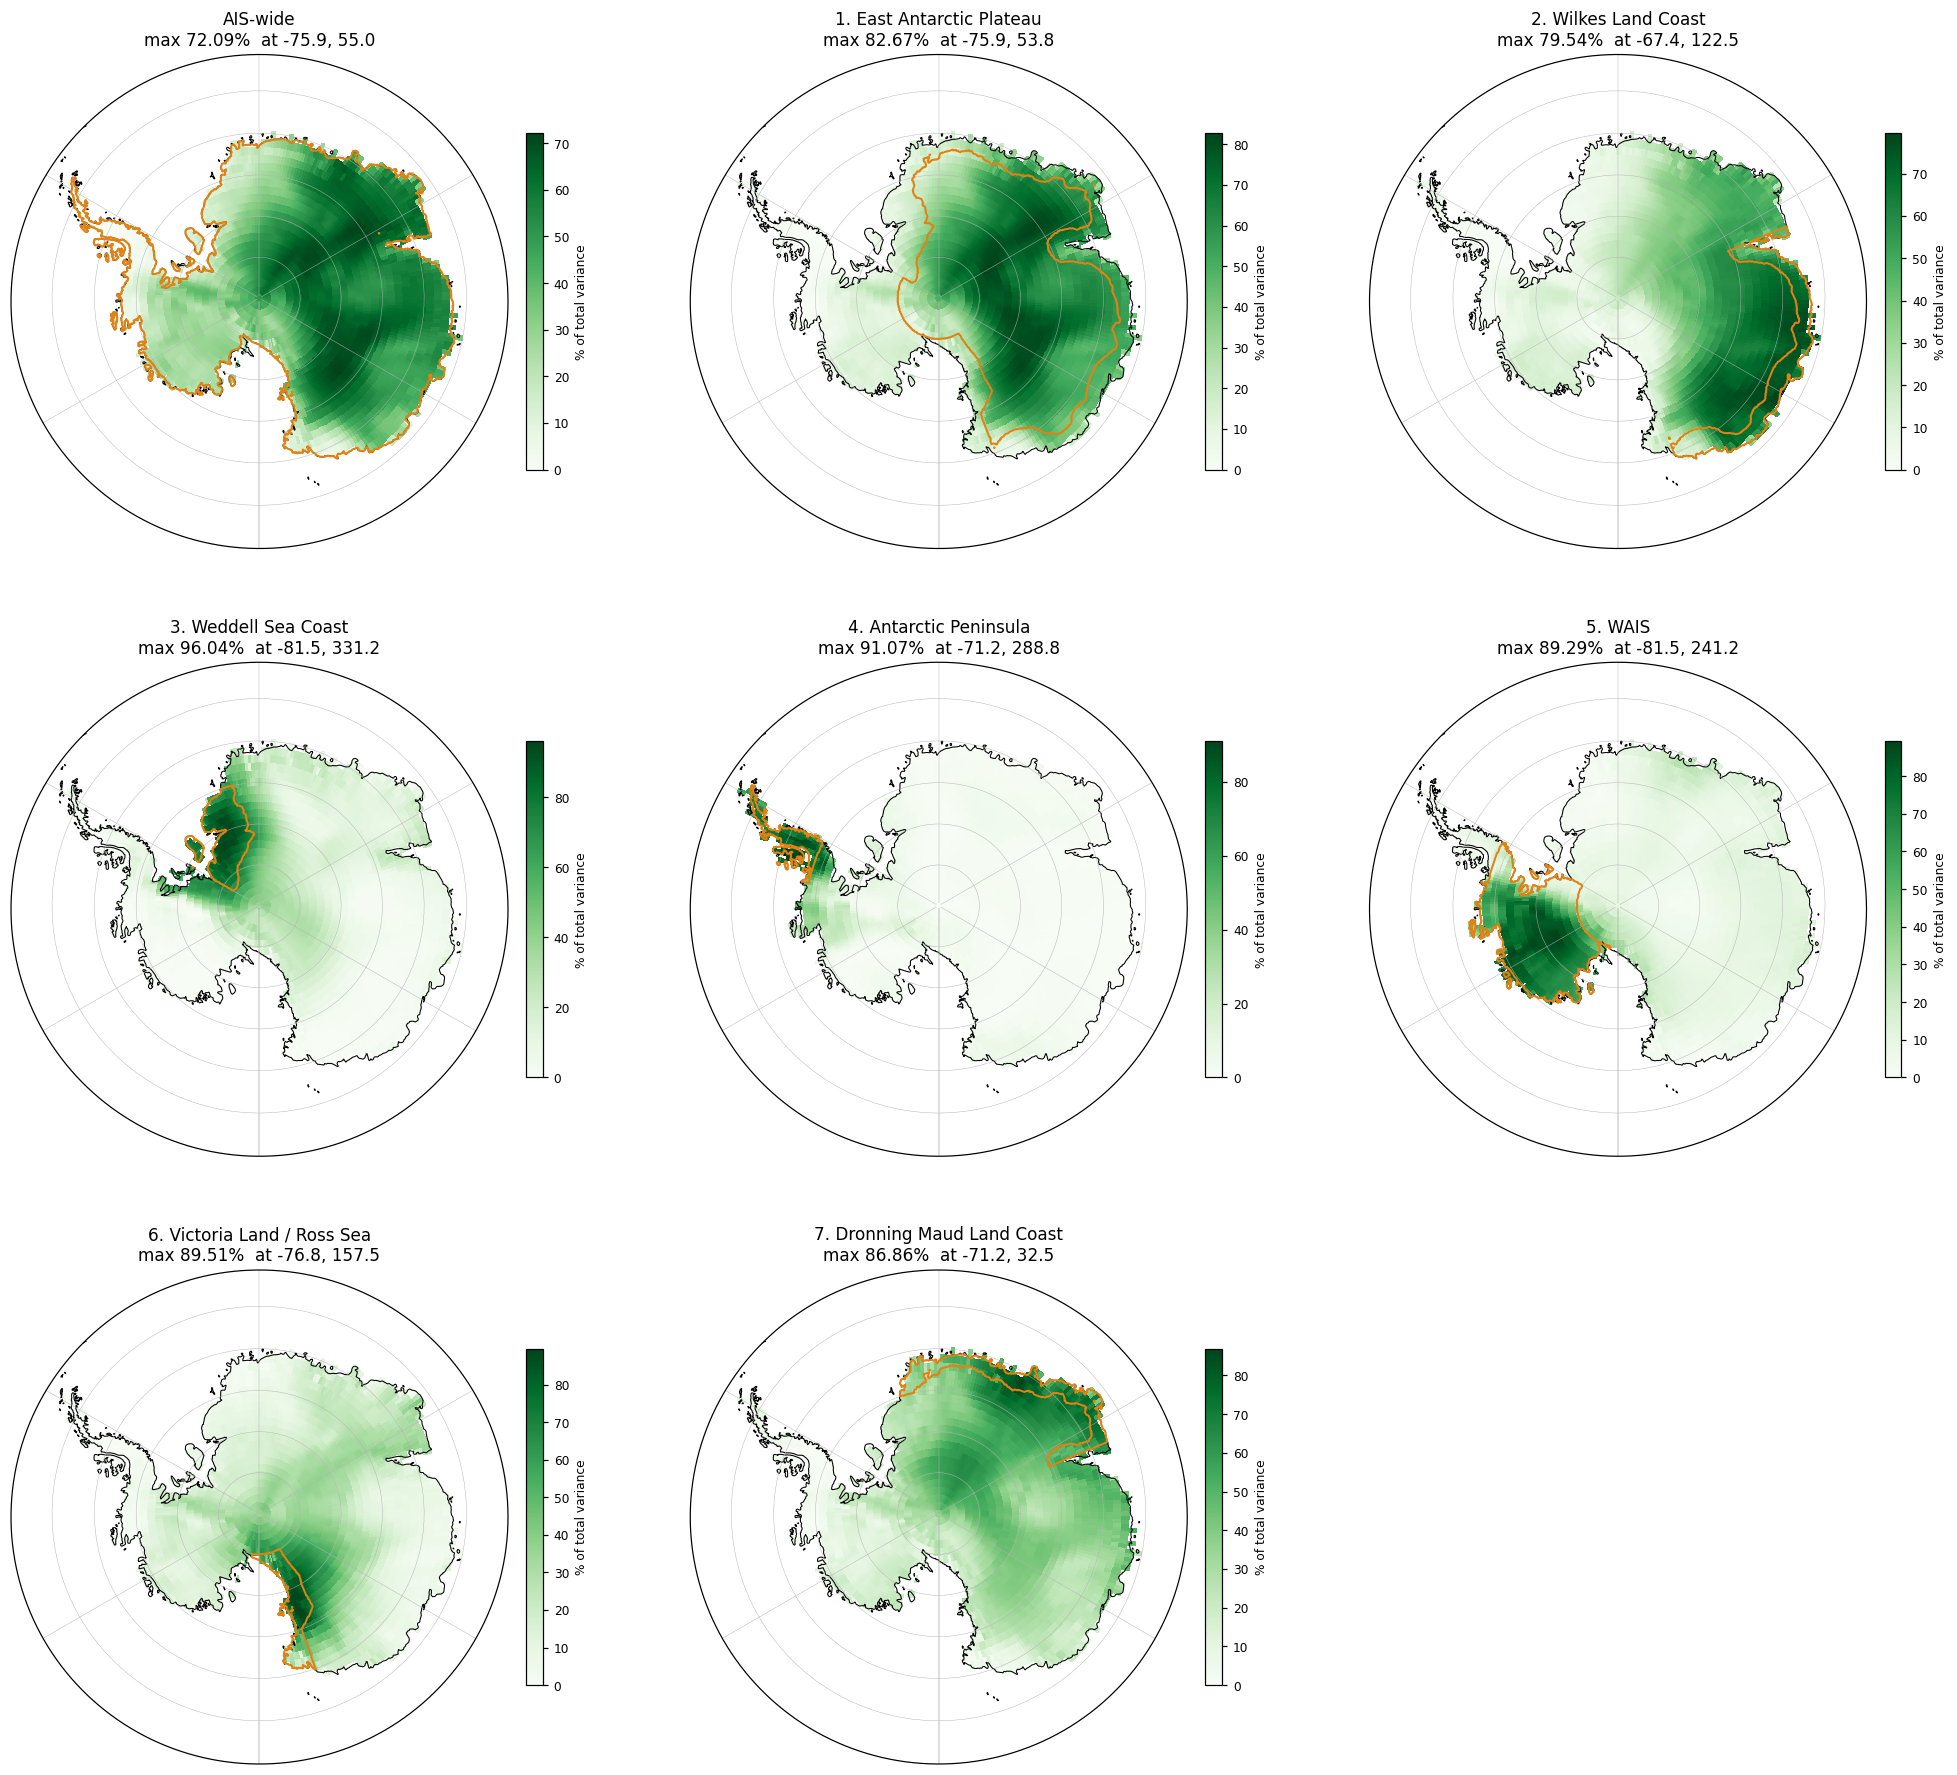

In [16]:
check_ens(); require('blank_panels')
blank_panels(R_AWS_NEW, f'blank slate: one new AWS, R = {R_AWS_NEW}')


## Given the AWS network


--- after AWS: one new ICE CORE (R_CORE_MODE=constant) ---
                     metric  aws_base  max_add    lat    lon  accum   R  in_region  mean_add
                   AIS-wide     94.47     1.16 -77.75 275.00 414.96 0.0       True      0.27
  1. East Antarctic Plateau     94.35     2.13 -81.52  47.50  23.41 0.0       True      0.38
       2. Wilkes Land Coast     95.07     1.67 -68.32 145.00 587.87 0.0       True      0.25
       3. Weddell Sea Coast     64.05    33.36 -81.52 331.25 114.18 0.0       True      2.04
     4. Antarctic Peninsula     82.51    14.06 -73.04 295.00 743.27 0.0       True      0.98
                    5. WAIS     89.54     4.80 -76.81 280.00 500.14 0.0       True      0.40
6. Victoria Land / Ross Sea     81.66    10.86 -76.81 158.75  72.08 0.0       True      0.77
7. Dronning Maud Land Coast     90.64     6.35 -71.15  26.25 374.84 0.0       True      0.72


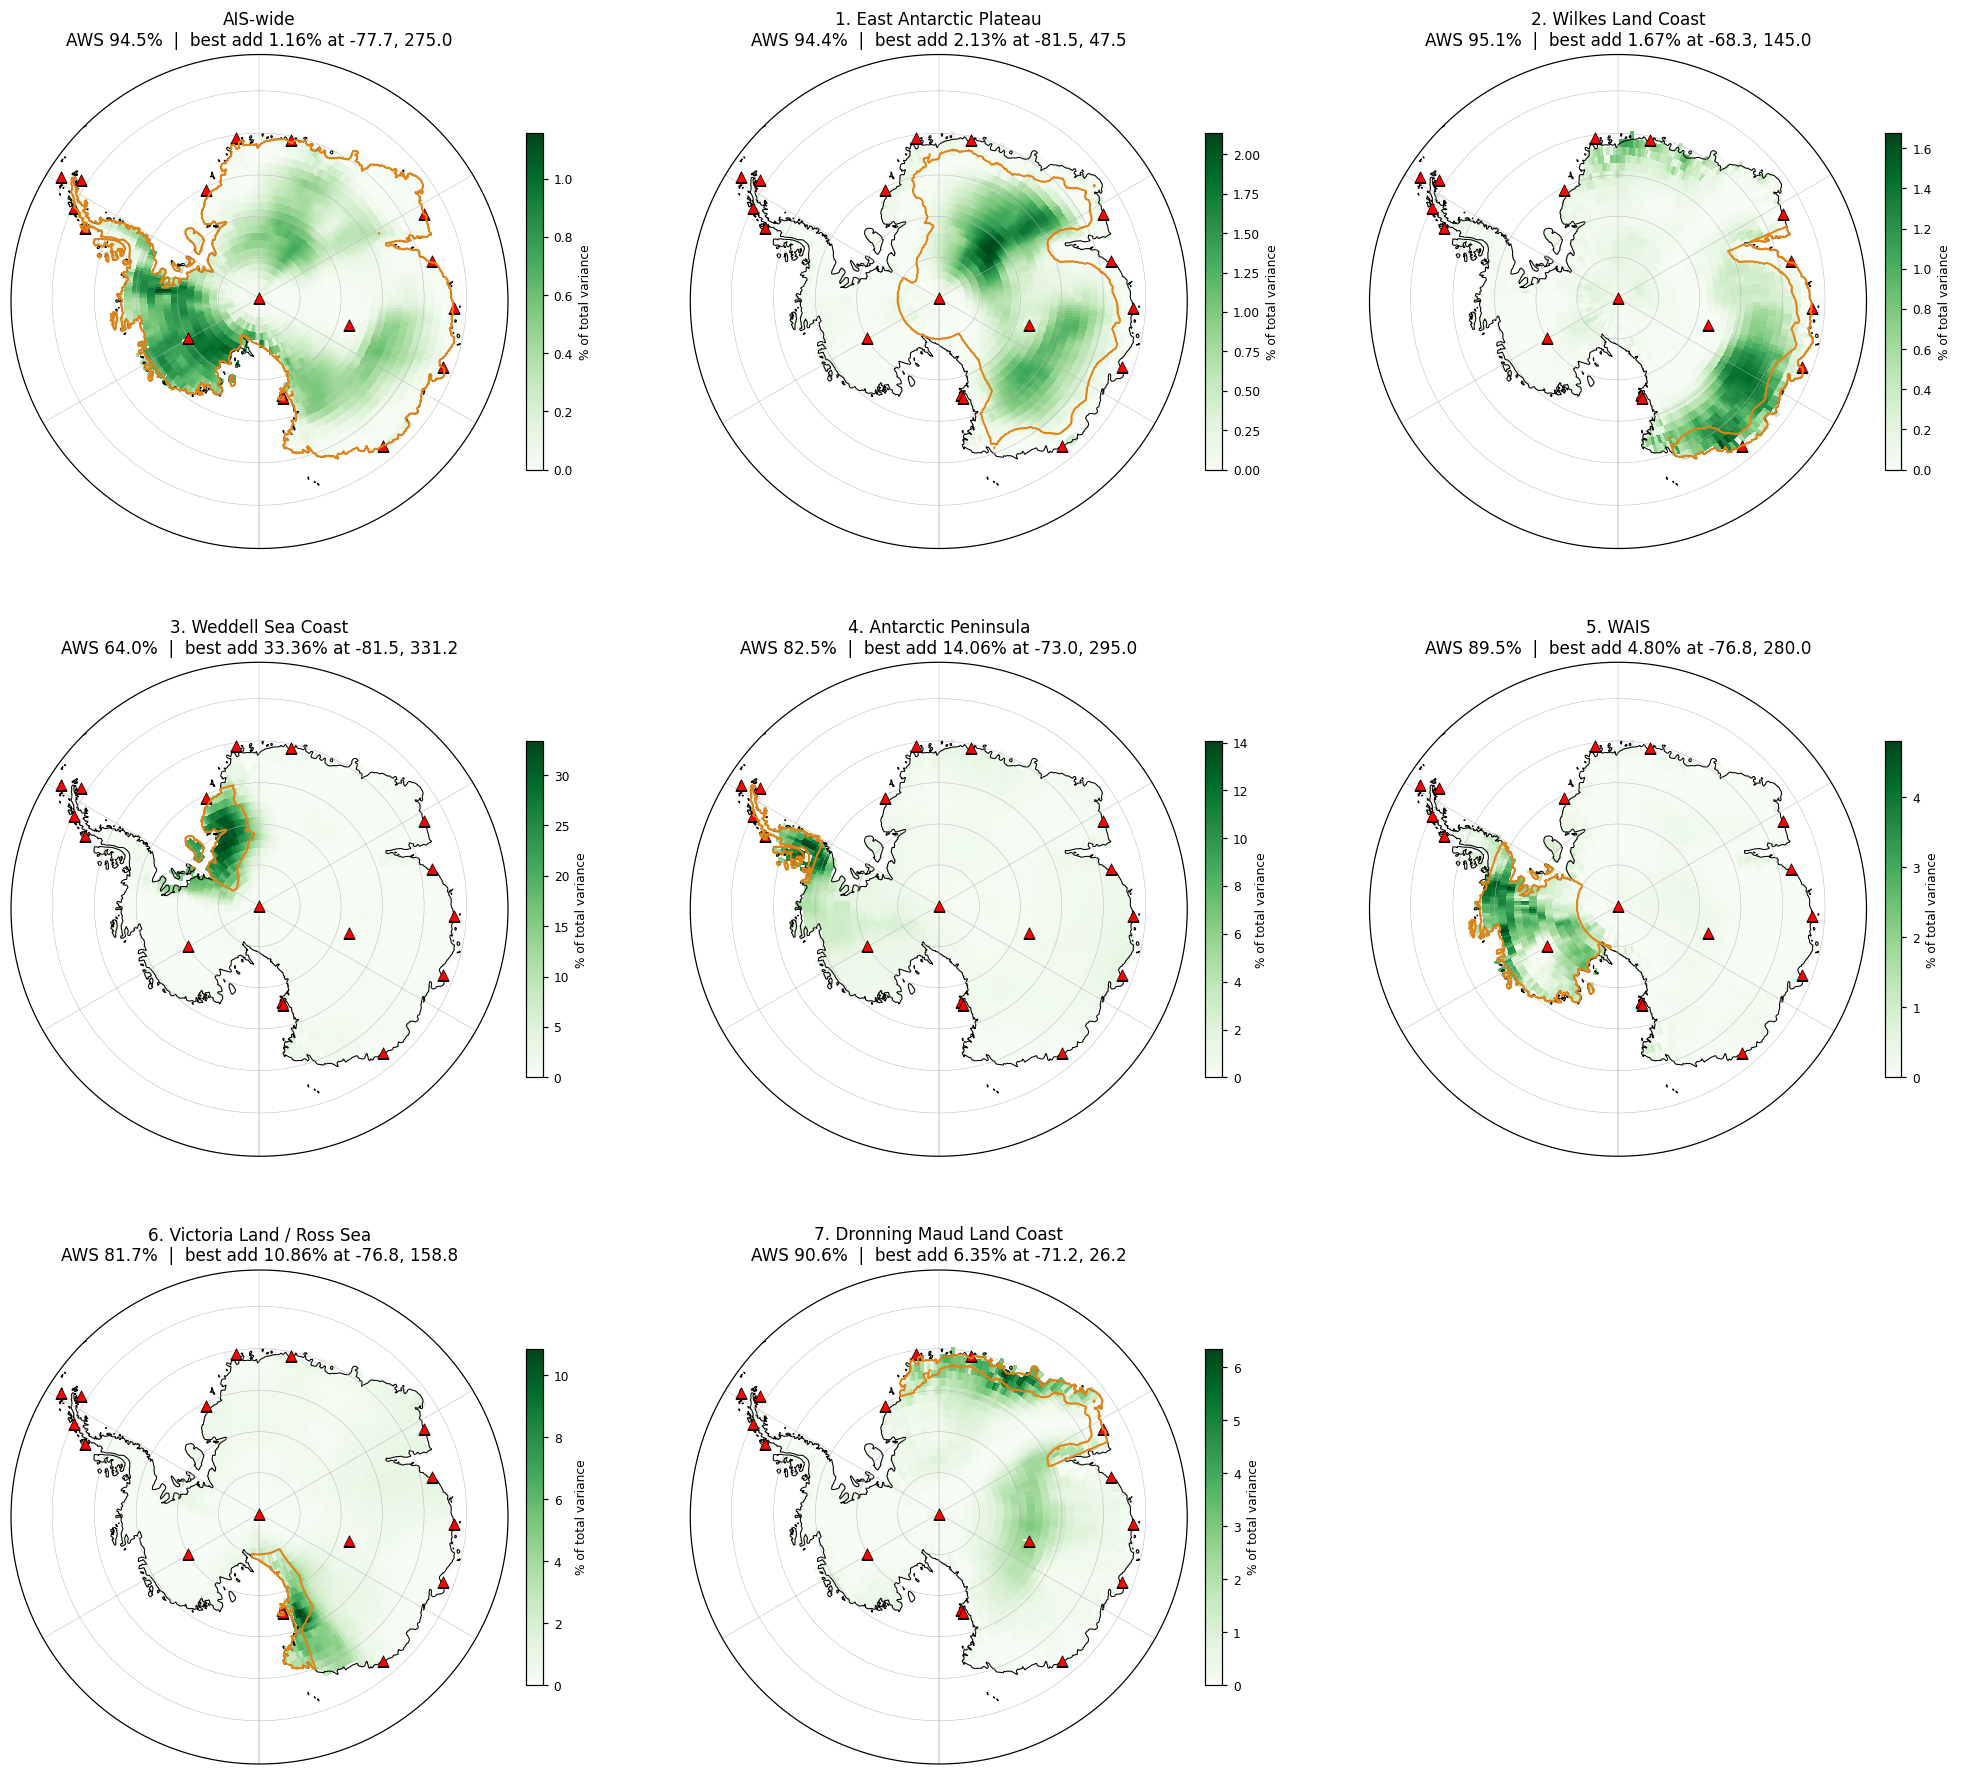

In [17]:
check_ens(); require('METS', 'outline_region', 'field_map')

def post_aws_panels(Rcand, label):
    """AWS network assimilated first, then one candidate at each grid cell.
    Values are percentage points of the metric's TOTAL variance."""
    fig = plt.figure(figsize=(19, 17)); rows = []
    for idx, (lbl, Jm, v) in enumerate(METS):
        ob = OptimalSensor(Jm, Ye[:N_POTENTIAL], Rcand)
        J0m = ob.J0var
        for i in AWS_SITES:
            ob.assimilate(int(i), Rval=R_aws(i))
        base = 100 * (1 - ob.metric_variance() / J0m)
        p = 100 * np.where(np.isfinite(ob.evaluate()), ob.evaluate(), np.nan) / J0m
        k = int(np.nanargmax(p))
        r_, c_ = divmod(idx, 3)
        ax = fig.add_axes([0.02 + c_*0.325, 0.68 - r_*0.325, 0.29, 0.29],
                          projection=SP)
        sc = field_map(p, f'{lbl}\nAWS {base:.1f}%  |  best add {p[k]:.2f}% at '
                          f'{site_lat[k]:.1f}, {site_lon[k]:.1f}',
                       ax=ax, fig=fig, cb=False, fs=11, show_aws=True)
        outline_region(ax, v)
        cb = fig.colorbar(sc, ax=ax, shrink=.62, pad=.03)
        cb.ax.tick_params(labelsize=8); cb.set_label('% of total variance', fontsize=8)
        rows.append(dict(metric=lbl, aws_base=base, max_add=p[k], lat=site_lat[k],
                         lon=site_lon[k], accum=accum_rate[k],
                         R=(Rcand[k] if np.ndim(Rcand) else Rcand),
                         in_region=(bool(p2k_mask[v][k]) if v else True),
                         mean_add=np.nansum(p*wts)/wts.sum()))
    print(f'--- {label} ---')
    print(pd.DataFrame(rows).round(2).to_string(index=False))
    plt.show()

post_aws_panels(R_ICE_CORE, f'after AWS: one new ICE CORE (R_CORE_MODE={R_CORE_MODE})')


## Minimum network to a threshold


threshold 95% of total variance, R_CORE_MODE=constant, nM=160, DOF cap 79

                     metric  aws_base  n  reached  n80  n85  in_region  capped  dof_pct
                   AIS-wide     94.47  1    95.63    1    1          1   False    10.69
  1. East Antarctic Plateau     94.35  1    96.48    1    1          1   False    10.69
       2. Wilkes Land Coast     95.07  0    95.07   -1   -1          0   False    10.06
       3. Weddell Sea Coast     64.05  1    97.41    1    1          1   False    10.69
     4. Antarctic Peninsula     82.51  1    96.56    1    1          1   False    10.69
                    5. WAIS     89.54  2    97.10    1    1          2   False    11.32
6. Victoria Land / Ross Sea     81.66  2    95.27    1    1          2   False    11.32
7. Dronning Maud Land Coast     90.64  1    96.99    1    1          1   False    10.69


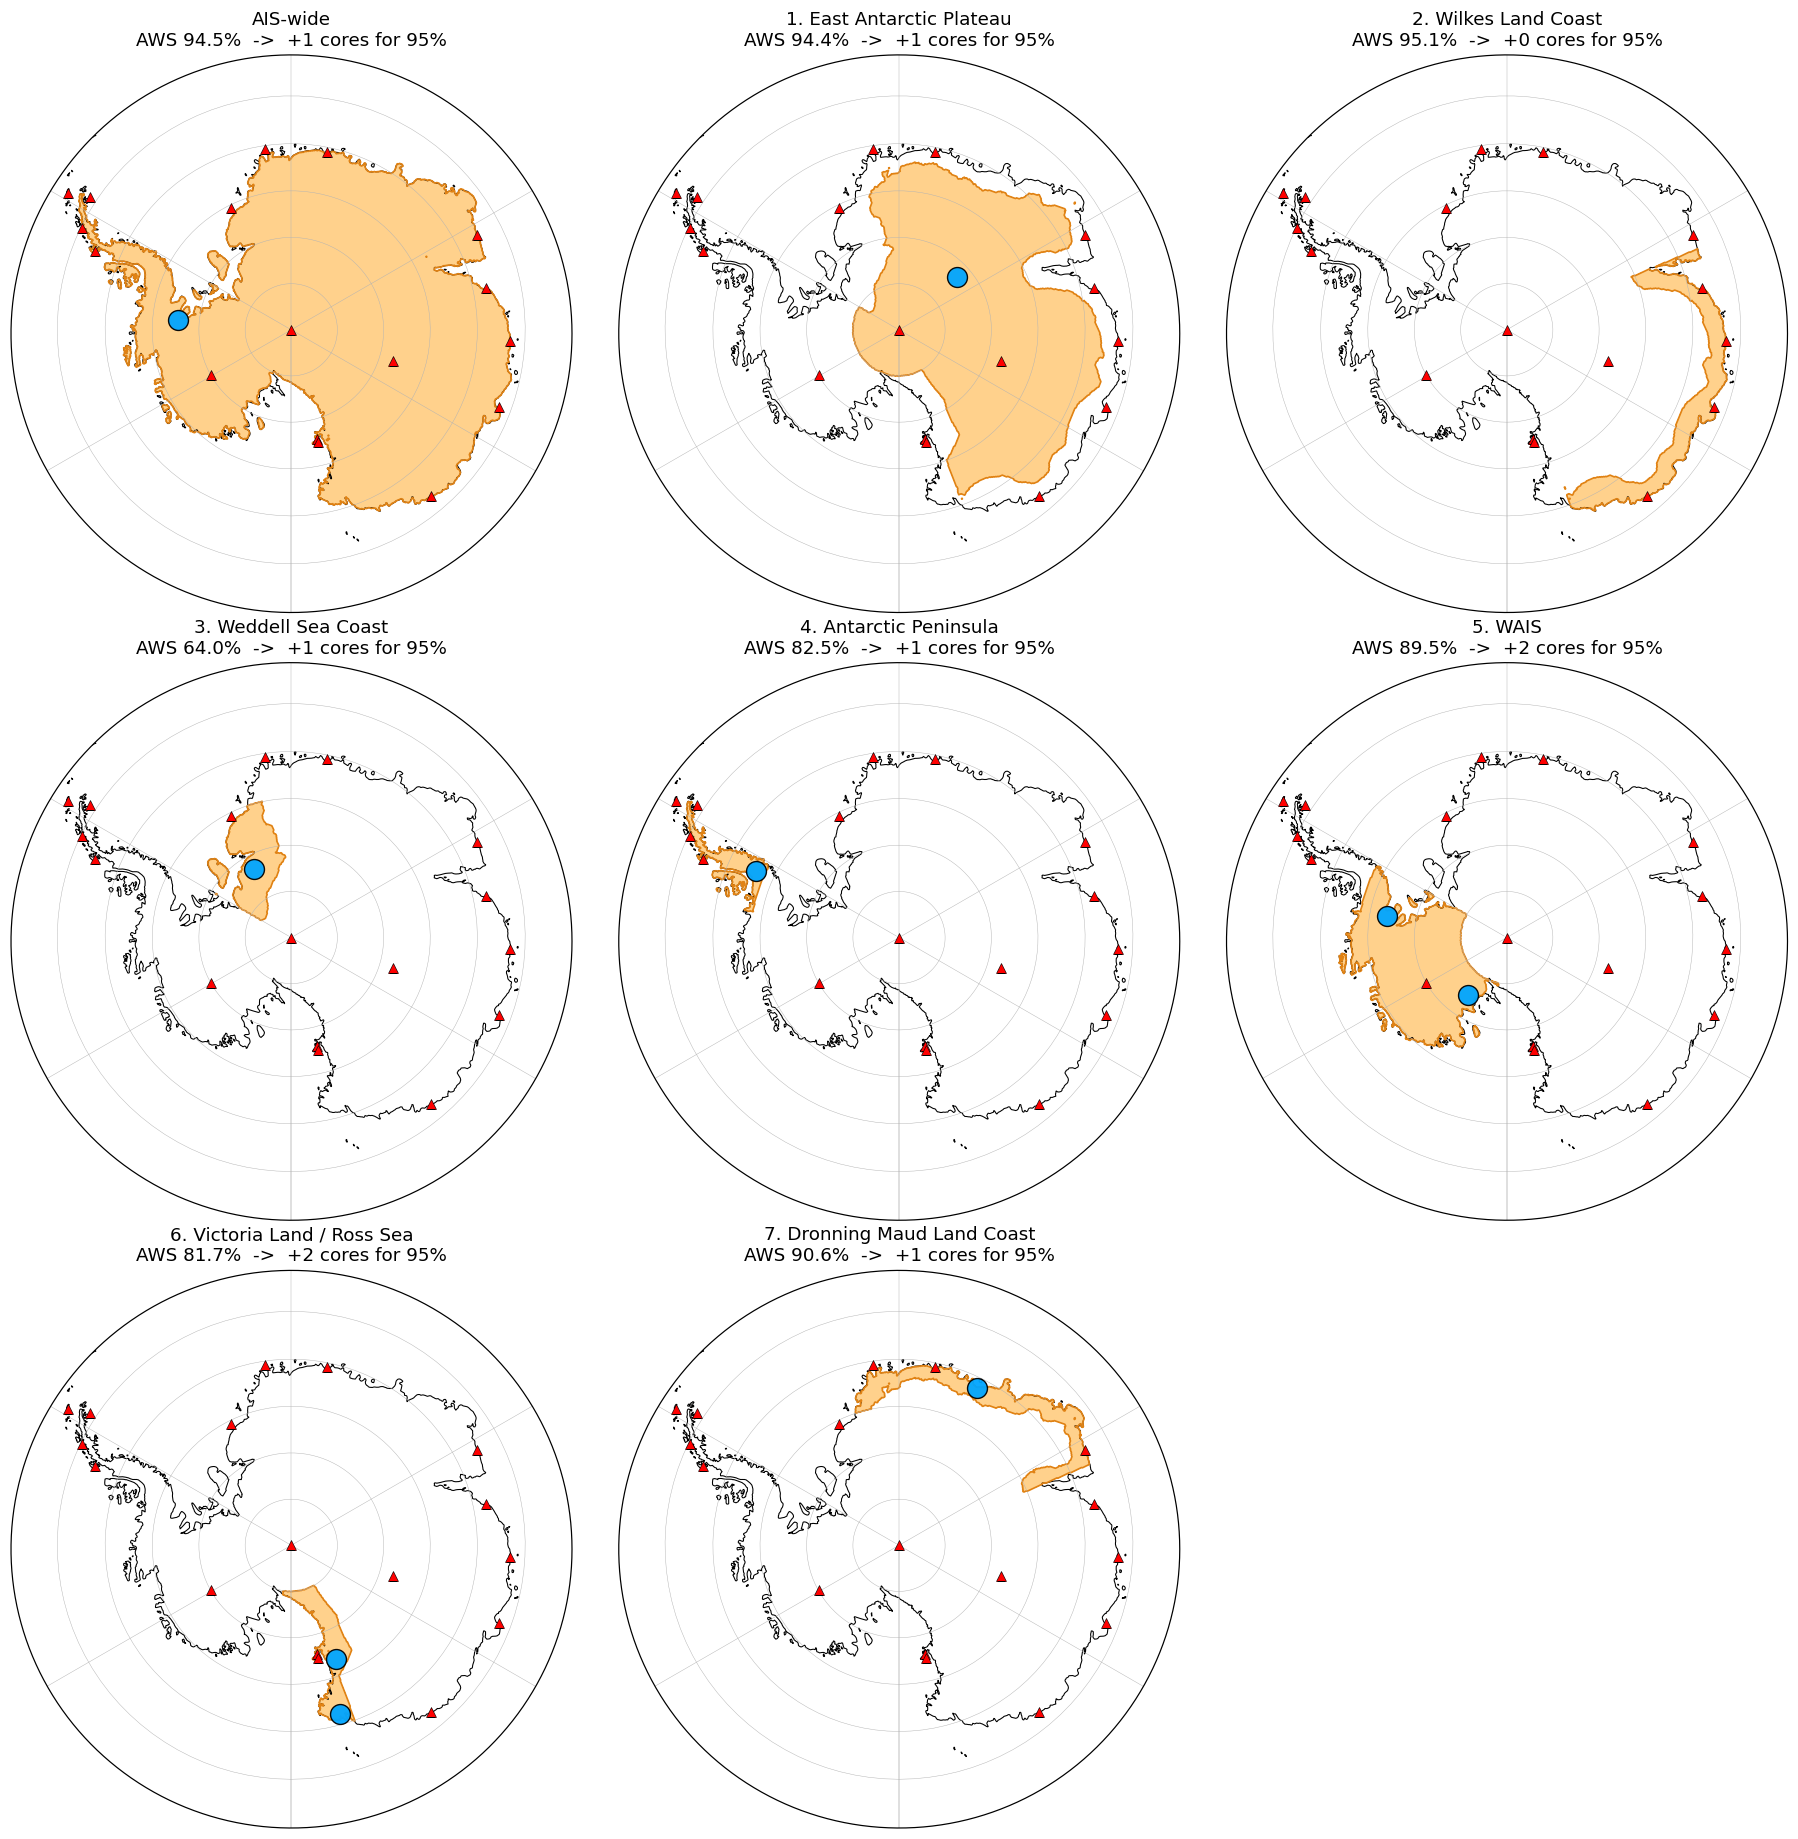

In [19]:
check_ens(); require('METS', 'fill_region', 'polar_ax')
THRESH, NMAX, DOF_LIMIT = 0.95, 400, 0.50
CORE_COLOR = '#00A5FF'
DOF_MAX = int(DOF_LIMIT * (nM - 1))
print(f'threshold {100*THRESH:.0f}% of total variance, R_CORE_MODE={R_CORE_MODE}, '
      f'nM={nM}, DOF cap {DOF_MAX}\n')

res, rows = {}, []
for lbl, Jm, v in METS:
    ob = OptimalSensor(Jm, Ye[:N_POTENTIAL], R_ICE_CORE)
    J0m = ob.J0var
    for i in AWS_SITES:
        ob.assimilate(int(i), Rval=R_aws(i))
    base = 100 * (1 - ob.metric_variance() / J0m)
    st, cum, capped = [], [], False
    for _ in range(0 if base >= 100*THRESH else NMAX):
        if len(AWS_SITES) + len(st) >= DOF_MAX:
            capped = True; break
        dv = np.where(np.isfinite(ob.evaluate()), ob.evaluate(), -np.inf)
        for k in st:
            dv[k] = -np.inf
        b = int(np.argmax(dv))
        if dv[b] <= 0:
            break
        vv = ob.assimilate(b); st.append(b)
        cum.append(100 * (1 - vv / J0m))
        if cum[-1] >= 100 * THRESH:
            break
    st, cum = np.array(st, int), np.array(cum)
    reached = cum[-1] if len(cum) else base
    res[lbl] = (st, cum, base, capped, v)
    hit = lambda p: (int(np.argmax(cum >= p)) + 1) if len(cum) and (cum >= p).any() else -1
    rows.append(dict(metric=lbl, aws_base=base, n=len(st), reached=reached,
                     n80=hit(80), n85=hit(85),
                     in_region=(int(p2k_mask[v][st].sum()) if v and len(st) else len(st)),
                     capped=capped,
                     dof_pct=100*(len(AWS_SITES)+len(st))/(nM-1)))
print(pd.DataFrame(rows).round(2).to_string(index=False))

fig = plt.figure(figsize=(17, 17))
for idx, (lbl, Jm, v) in enumerate(METS):
    st, cum, base, capped, _ = res[lbl]
    r_, c_ = divmod(idx, 3)
    ax = fig.add_axes([0.02 + c_*0.325, 0.68 - r_*0.325, 0.30, 0.30], projection=SP)
    polar_ax(ax); fill_region(ax, v)
    ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=42, c='red', edgecolors='k',
               lw=.4, transform=PL, zorder=2)
    if len(st):
        ax.scatter(site_lon[st], site_lat[st], s=170, c=CORE_COLOR, edgecolors='k',
                   lw=.9, transform=PL, zorder=4, alpha=.95)
    r2 = cum[-1] if len(cum) else base
    tail = f'{100*THRESH:.0f}%' if not capped else f'DOF cap, {r2:.1f}%'
    ax.set_title(f'{lbl}\nAWS {base:.1f}%  ->  +{len(st)} cores for {tail}', fontsize=12)
plt.show()


REDRILLING ONLY: candidates restricted to the 63 existing core cells. threshold 95% of total variance, DOF cap 79

                     metric  aws_base  n  reached  hit_target  n80  n85  exhausted  capped          first
                   AIS-wide     94.47  1    95.44        True    1    1      False   False     ITASE-99-1
  1. East Antarctic Plateau     94.35  1    95.83        True    1    1      False   False Plateau Remote
       2. Wilkes Land Coast     95.07  1    96.02        True    1    1      False   False        DML S20
       3. Weddell Sea Coast     64.05 61    92.73       False    1    1       True   False Berkner Island
     4. Antarctic Peninsula     82.51  2    95.67        True    1    1      False   False          Gomez
                    5. WAIS     89.54  2    96.90        True    1    1      False   False  Siple Station
6. Victoria Land / Ross Sea     81.66 61    94.19       False    1    1       True   False            VLG
7. Dronning Maud Land Coast     90.64

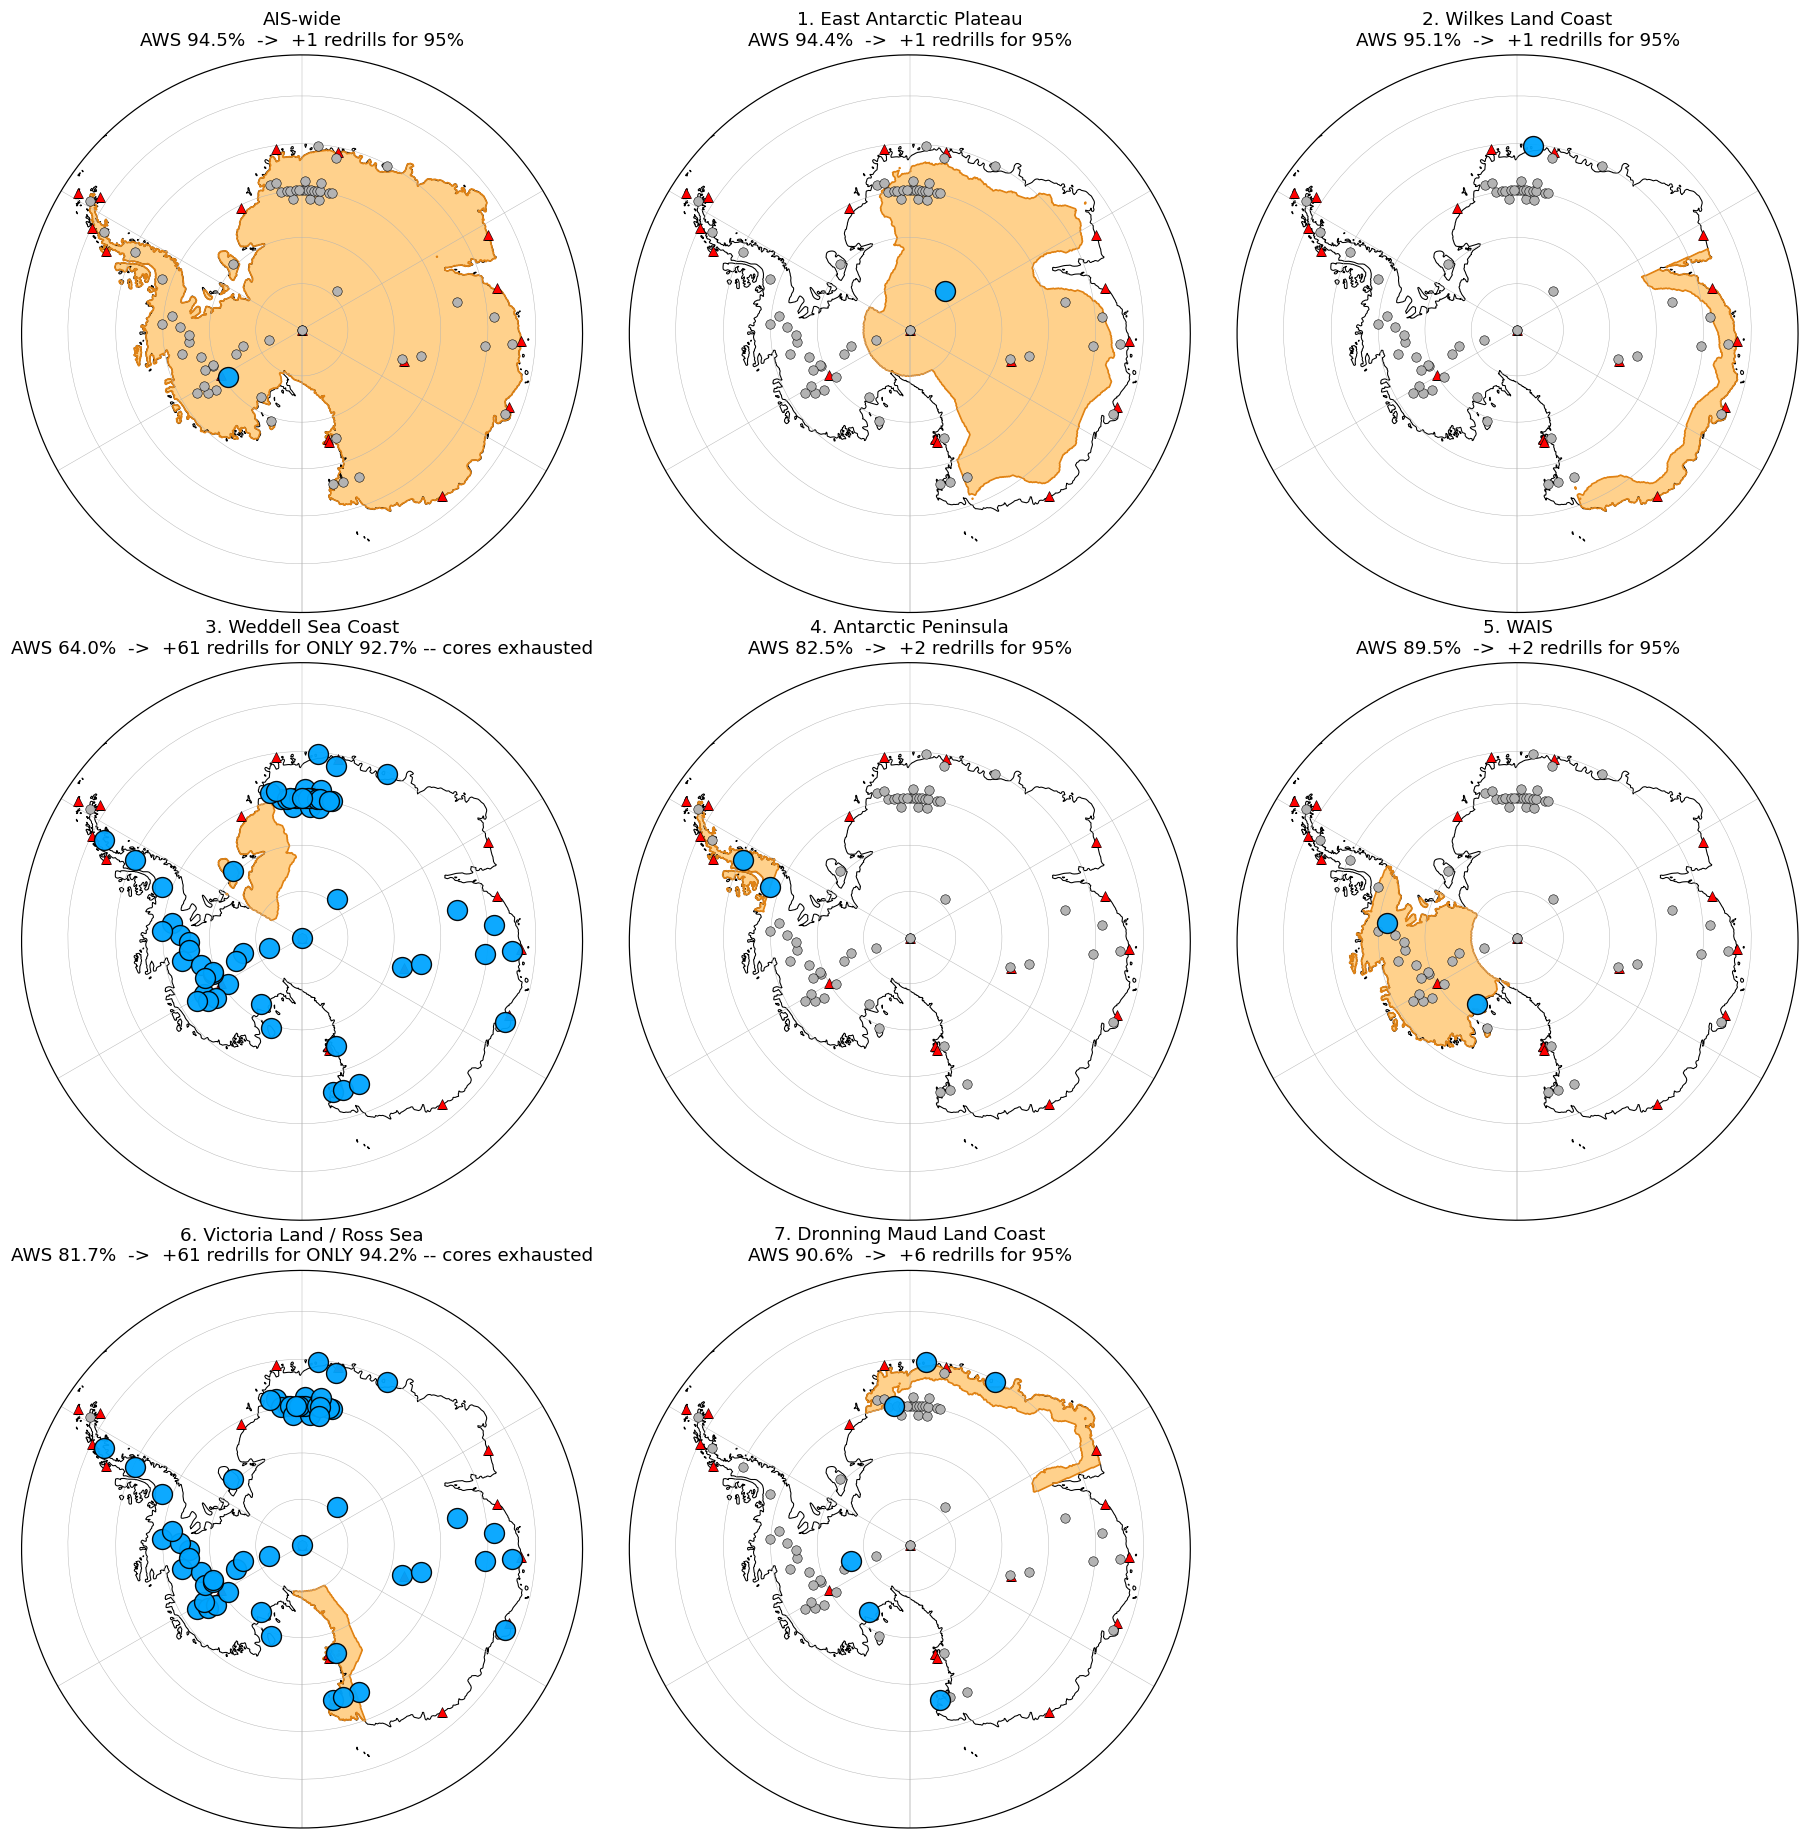

In [20]:
check_ens(); require('METS', 'fill_region', 'polar_ax', 'CORE_SITES', 'core_mask', 'name_of')
THRESH, NMAX, DOF_LIMIT = 0.95, 400, 0.50
CORE_COLOR = '#00A5FF'
DOF_MAX = int(DOF_LIMIT * (nM - 1))
print(f'REDRILLING ONLY: candidates restricted to the {len(CORE_SITES)} existing '
      f'core cells. threshold {100*THRESH:.0f}% of total variance, DOF cap {DOF_MAX}\n')

res, rows = {}, []
for lbl, Jm, v in METS:
    ob = OptimalSensor(Jm, Ye[:N_POTENTIAL], R_ICE_CORE)
    J0m = ob.J0var
    for i in AWS_SITES:
        ob.assimilate(int(i), Rval=R_aws(i))
    base = 100 * (1 - ob.metric_variance() / J0m)
    st, cum, capped, exhausted = [], [], False, False
    for _ in range(NMAX):
        if len(AWS_SITES) + len(st) >= DOF_MAX:
            capped = True; break
        dv = np.where(np.isfinite(ob.evaluate()), ob.evaluate(), -np.inf)
        dv = np.where(core_mask, dv, -np.inf)          # <- the restriction
        for k in st:
            dv[k] = -np.inf
        b = int(np.argmax(dv))
        if not np.isfinite(dv[b]) or dv[b] <= 0:
            exhausted = True; break
        vv = ob.assimilate(b); st.append(b)
        cum.append(100 * (1 - vv / J0m))
        if cum[-1] >= 100 * THRESH:
            break
    st, cum = np.array(st), np.array(cum)
    reached = cum[-1] if len(cum) else base
    res[lbl] = (st, cum, base, capped, exhausted, v)
    hit = lambda p: (int(np.argmax(cum >= p)) + 1) if len(cum) and (cum >= p).any() else -1
    rows.append(dict(metric=lbl, aws_base=base, n=len(st), reached=reached,
                     hit_target=bool(reached >= 100*THRESH), n80=hit(80), n85=hit(85),
                     exhausted=exhausted, capped=capped,
                     first=(name_of[int(st[0])] if len(st) else '-')))
print(pd.DataFrame(rows).round(2).to_string(index=False))

fig = plt.figure(figsize=(17, 17))
for idx, (lbl, Jm, v) in enumerate(METS):
    st, cum, base, capped, exhausted, _ = res[lbl]
    r_, c_ = divmod(idx, 3)
    ax = fig.add_axes([0.02 + c_*0.325, 0.68 - r_*0.325, 0.30, 0.30], projection=SP)
    polar_ax(ax)
    fill_region(ax, v)
    ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=42, c='red', edgecolors='k',
               lw=.4, transform=PL, zorder=2)
    other = [k for k in CORE_SITES if k not in set(st)]
    ax.scatter(site_lon[other], site_lat[other], s=38, c='0.7', edgecolors='k',
               lw=.35, transform=PL, zorder=3)
    if len(st):
        ax.scatter(site_lon[st], site_lat[st], s=170, c=CORE_COLOR, edgecolors='k',
                   lw=.9, transform=PL, zorder=4, alpha=.95)
    r2 = cum[-1] if len(cum) else base
    tail = (f'{100*THRESH:.0f}%' if r2 >= 100*THRESH else
            (f'DOF cap, {r2:.1f}%' if capped else
             f'ONLY {r2:.1f}% -- cores exhausted'))
    ax.set_title(f'{lbl}\nAWS {base:.1f}%  ->  +{len(st)} redrills for {tail}',
                 fontsize=12)
plt.show()


HYBRID: budget fixed to the unconstrained n, redrills preferred within it.
threshold 95% of total variance, DOF cap 79

                     metric  aws_base  n  free_reached  hybrid_reached  redrills  new_sites  free_redrills
                   AIS-wide     94.47  1         95.63           95.44         1          0              0
  1. East Antarctic Plateau     94.35  1         96.48           95.83         1          0              0
       2. Wilkes Land Coast     95.07  0         95.07           95.07         0          0              0
       3. Weddell Sea Coast     64.05  1         97.41           97.41         0          1              0
     4. Antarctic Peninsula     82.51  1         96.56           96.56         0          1              0
                    5. WAIS     89.54  2         97.10           96.90         2          0              0
6. Victoria Land / Ross Sea     81.66  2         95.27           95.27         0          2              0
7. Dronning Maud Land Co

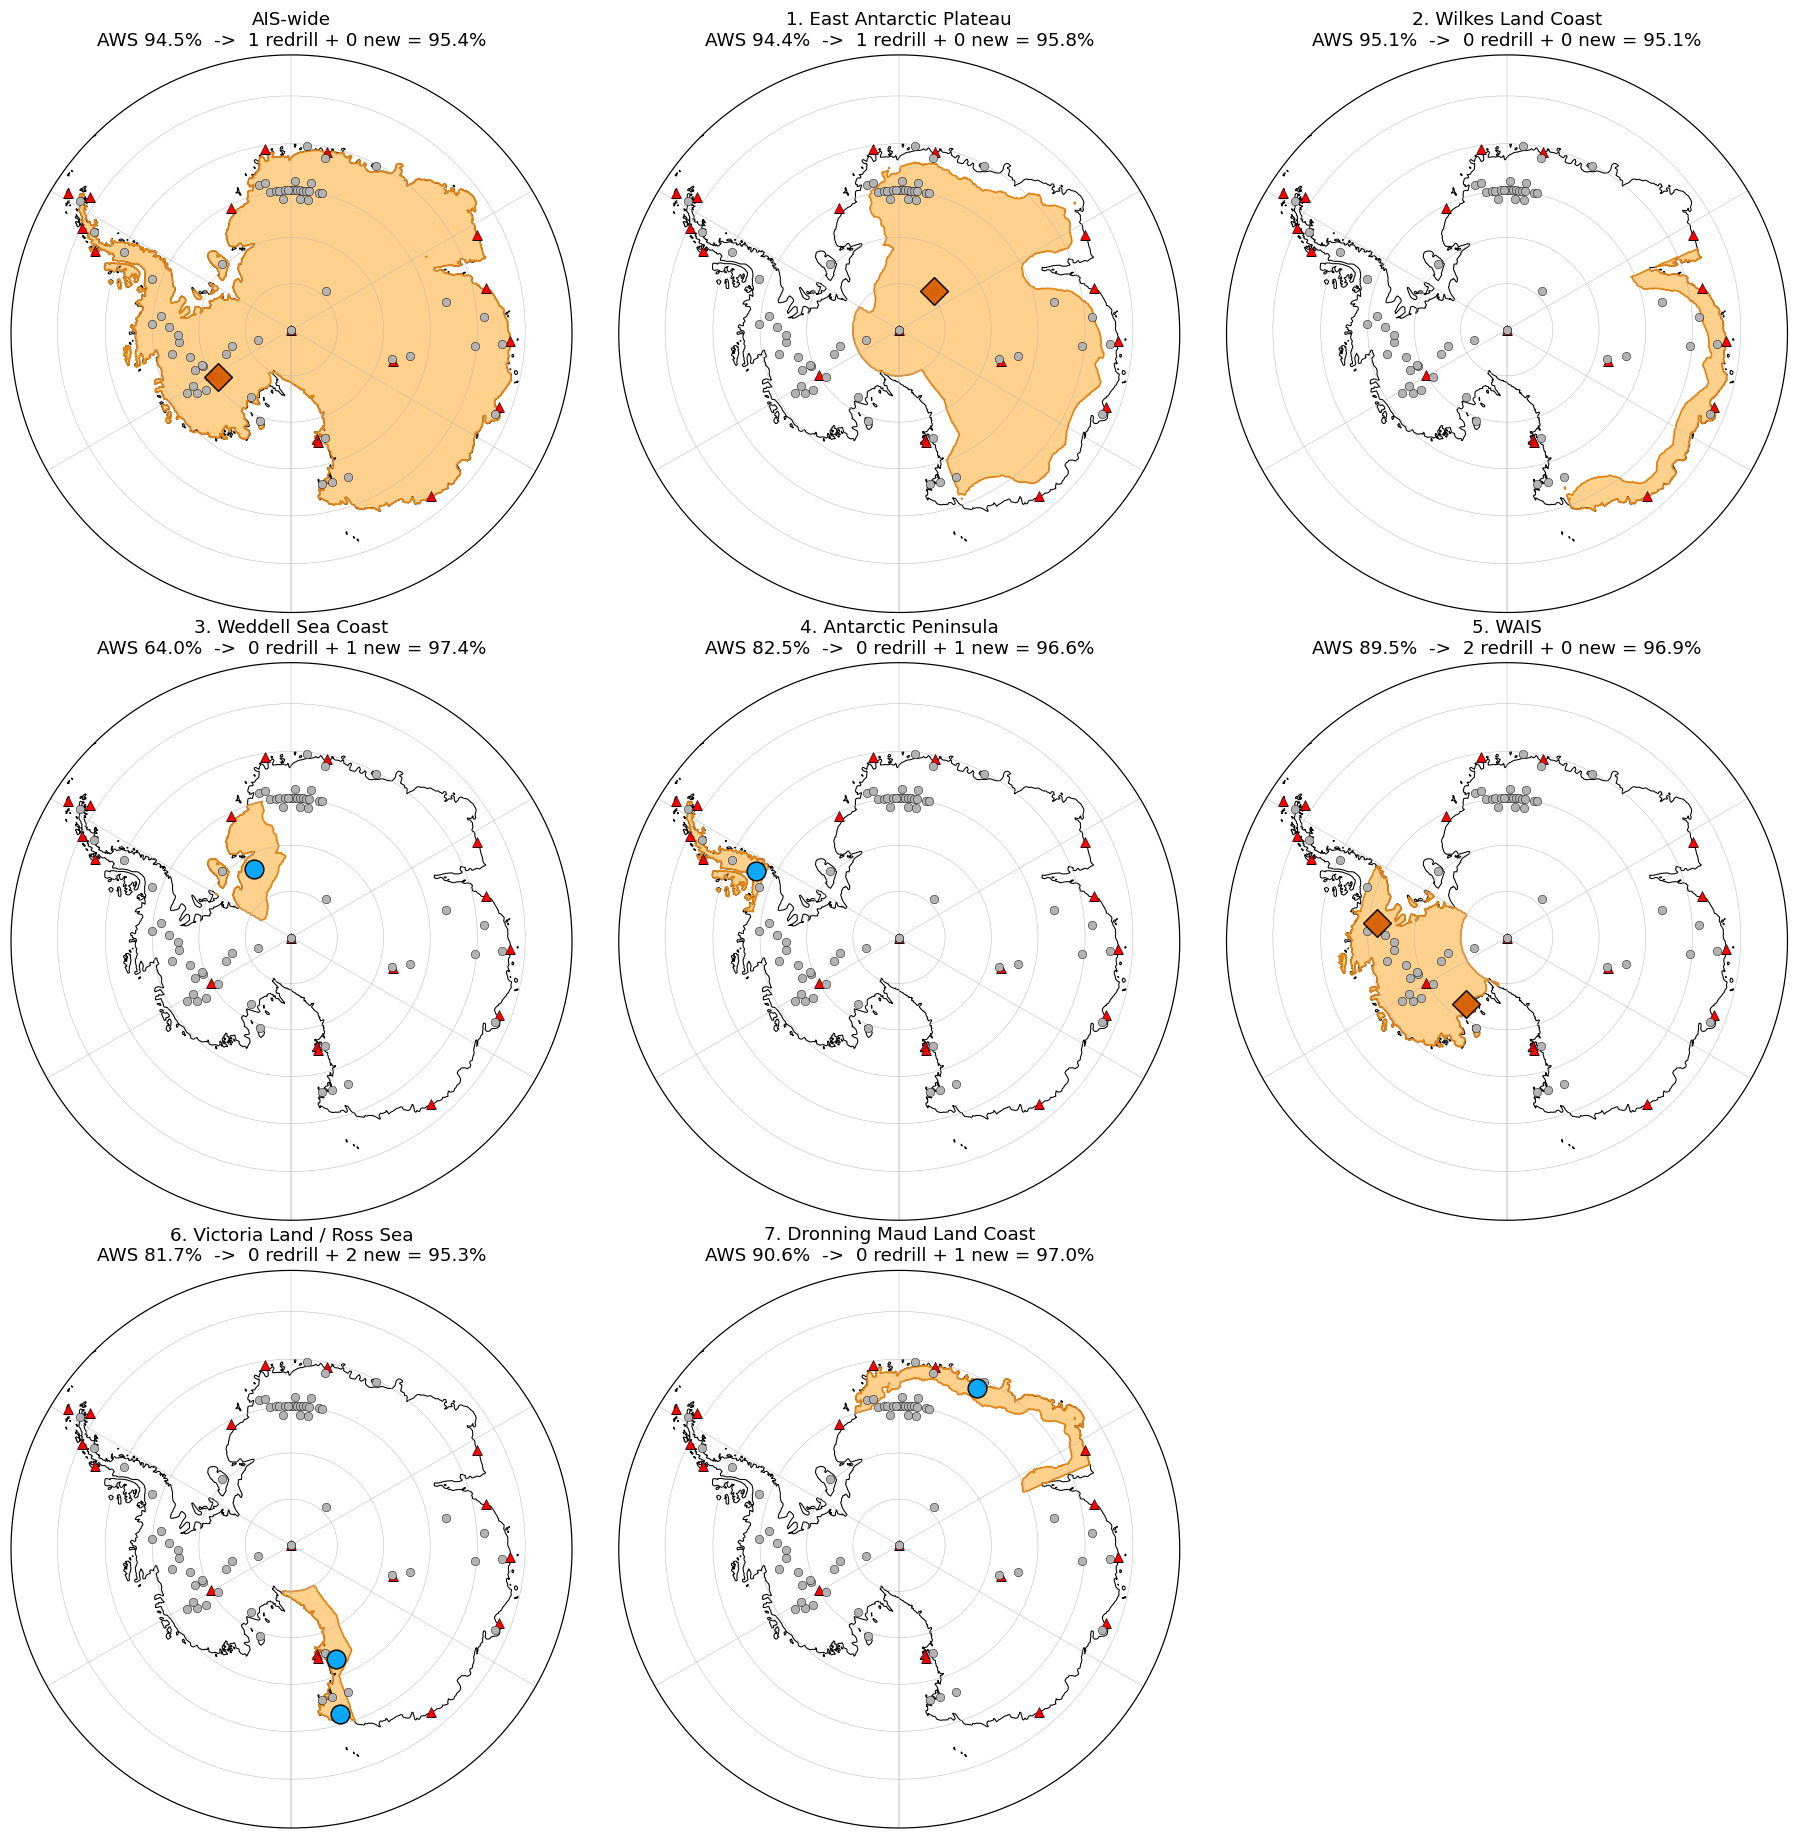


SITES TO REDRILL
                                           core    lat     lon   accum    R  cores_in_cell          also
metric                    order                                                                         
AIS-wide                  1          ITASE-99-1 -80.58  237.50  117.60  0.0              1              
1. East Antarctic Plateau 1      Plateau Remote -84.35   42.50   33.25  0.0              1              
5. WAIS                   1       Siple Station -75.86  276.25  631.87  0.0              1              
                          2        Siple Dome A -81.52  211.25  119.50  0.0              2  Siple Dome B

cores selected for more than one metric:
  (none)


In [21]:
check_ens(); require('METS', 'fill_region', 'polar_ax', 'CORE_SITES', 'core_mask', 'name_of')
import copy
THRESH, NMAX, DOF_LIMIT = 0.95, 400, 0.50
CORE_COLOR, REDRILL_COLOR = '#00A5FF', '#d95f02'
DOF_MAX = int(DOF_LIMIT * (nM - 1))
print(f'HYBRID: budget fixed to the unconstrained n, redrills preferred within it.\n'
      f'threshold {100*THRESH:.0f}% of total variance, DOF cap {DOF_MAX}\n')

def reachable(ob, J0m, budget, used):
    """Greedy lower bound on the % reachable with `budget` more FREE picks."""
    o = copy.deepcopy(ob); us = set(used)
    best = 100 * (1 - o.metric_variance() / J0m)
    for _ in range(budget):
        dv = np.where(np.isfinite(o.evaluate()), o.evaluate(), -np.inf)
        for k in us:
            dv[k] = -np.inf
        b = int(np.argmax(dv))
        if not np.isfinite(dv[b]) or dv[b] <= 0:
            break
        best = 100 * (1 - o.assimilate(b) / J0m); us.add(b)
    return best

res, rows = {}, []
for lbl, Jm, v in METS:
    ob = OptimalSensor(Jm, Ye[:N_POTENTIAL], R_ICE_CORE)
    J0m = ob.J0var
    for i in AWS_SITES:
        ob.assimilate(int(i), Rval=R_aws(i))
    base = 100 * (1 - ob.metric_variance() / J0m)

    # --- 1) unconstrained run: sets the budget ---
    free, st_f = copy.deepcopy(ob), []
    for _ in range(0 if base >= 100*THRESH else NMAX):
        if len(AWS_SITES) + len(st_f) >= DOF_MAX:
            break
        dv = np.where(np.isfinite(free.evaluate()), free.evaluate(), -np.inf)
        for k in st_f:
            dv[k] = -np.inf
        b = int(np.argmax(dv))
        if dv[b] <= 0:
            break
        vv = free.assimilate(b); st_f.append(b)
        if 100 * (1 - vv / J0m) >= 100 * THRESH:
            break
    n_free = len(st_f)
    reach_free = 100 * (1 - free.metric_variance() / J0m)

    # --- 2) hybrid: same budget, redrill whenever it stays feasible ---
    hy, st_h, kinds = copy.deepcopy(ob), [], []
    for step in range(n_free):
        left = n_free - step - 1
        dvc = np.where(np.isfinite(hy.evaluate()), hy.evaluate(), -np.inf)
        dvc = np.where(core_mask, dvc, -np.inf)
        for k in st_h:
            dvc[k] = -np.inf
        bc = int(np.argmax(dvc)); took = None
        if np.isfinite(dvc[bc]) and dvc[bc] > 0:
            trial = copy.deepcopy(hy); trial.assimilate(bc)
            if reachable(trial, J0m, left, set(st_h) | {bc}) >= 100*THRESH - 1e-9:
                took = bc; kinds.append('redrill')
        if took is None:
            dv = np.where(np.isfinite(hy.evaluate()), hy.evaluate(), -np.inf)
            for k in st_h:
                dv[k] = -np.inf
            took = int(np.argmax(dv)); kinds.append('new')
        hy.assimilate(took); st_h.append(took)
    st_h = np.array(st_h, int)
    reach_h = 100 * (1 - hy.metric_variance() / J0m) if n_free else base
    res[lbl] = (st_h, kinds, base, reach_h, v)
    rows.append(dict(metric=lbl, aws_base=base, n=n_free, free_reached=reach_free,
                     hybrid_reached=reach_h, redrills=kinds.count('redrill'),
                     new_sites=kinds.count('new'),
                     free_redrills=int(core_mask[st_f].sum()) if n_free else 0))
print(pd.DataFrame(rows).round(2).to_string(index=False))

fig = plt.figure(figsize=(17, 17))
for idx, (lbl, Jm, v) in enumerate(METS):
    st_h, kinds, base, reach_h, _ = res[lbl]
    r_, c_ = divmod(idx, 3)
    ax = fig.add_axes([0.02 + c_*0.325, 0.68 - r_*0.325, 0.30, 0.30], projection=SP)
    polar_ax(ax); fill_region(ax, v)
    ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=42, c='red', edgecolors='k',
               lw=.4, transform=PL, zorder=2)
    ax.scatter(site_lon[CORE_SITES], site_lat[CORE_SITES], s=30, c='0.7',
               edgecolors='k', lw=.3, transform=PL, zorder=3)
    if len(st_h):
        kk = np.array(kinds)
        for sel, col, mk, sz in [(kk == 'new', CORE_COLOR, 'o', 150),
                                 (kk == 'redrill', REDRILL_COLOR, 'D', 165)]:
            if sel.any():
                ax.scatter(site_lon[st_h[sel]], site_lat[st_h[sel]], s=sz, c=col,
                           marker=mk, edgecolors='k', lw=1.0, transform=PL,
                           zorder=4, alpha=.95)
    ax.set_title(f'{lbl}\nAWS {base:.1f}%  ->  {kinds.count("redrill")} redrill + '
                 f'{kinds.count("new")} new = {reach_h:.1f}%', fontsize=12)
plt.show()

print('\n' + '='*74)
print('SITES TO REDRILL')
print('='*74)
det = []
for lbl, Jm, v in METS:
    st_h, kinds, base, reach_h, _ = res[lbl]
    for o, (k, kind) in enumerate(zip(st_h, kinds), 1):
        if kind != 'redrill':
            continue
        nm = name_of.get(int(k), '?')
        alts = sorted({n for s_, n in zip(cc.site, cc.name) if int(s_) == int(k)})
        det.append(dict(metric=lbl, order=o, core=nm,
                        lat=site_lat[k], lon=site_lon[k],
                        accum=accum_rate[k], R=R_ICE_CORE[k],
                        cores_in_cell=len(alts),
                        also='; '.join(a for a in alts if a != nm)[:38]))
D = pd.DataFrame(det)
if len(D):
    print(D.set_index(['metric', 'order']).round(2).to_string())
    vc = D.core.value_counts()
    print('\ncores selected for more than one metric:')
    if (vc > 1).any():
        for nm, c in vc[vc > 1].items():
            print(f'  {nm:22s} {c} metrics: ' + ', '.join(D[D.core == nm].metric))
    else:
        print('  (none)')
else:
    print('no redrills selected')

